In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder

import warnings
warnings.filterwarnings("ignore")

In [2]:
orders = pd.read_csv("olist_orders_dataset.csv")
order_items = pd.read_csv("olist_order_items_dataset.csv")
products = pd.read_csv("olist_products_dataset.csv")
customers = pd.read_csv("olist_customers_dataset.csv")
reviews = pd.read_csv("olist_order_reviews_dataset.csv")
payments = pd.read_csv("olist_order_payments_dataset.csv")
sellers = pd.read_csv("olist_sellers_dataset.csv")
categories = pd.read_csv("product_category_name_translation.csv")

# Handling Missing Values

order table

In [5]:
orders.describe()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
count,99441,99441,99441,99441,99281,97658,96476,99441
unique,99441,99441,8,98875,90733,81018,95664,459
top,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2018-04-11 10:48:14,2018-02-27 04:31:10,2018-05-09 15:48:00,2018-05-08 23:38:46,2017-12-20 00:00:00
freq,1,1,96478,3,9,47,3,522


In [6]:
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB


In [7]:
orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [8]:
orders.isna().sum()

order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64

In [9]:
 
orders['order_purchase_timestamp'] = pd.to_datetime(orders['order_purchase_timestamp'])
orders['order_approved_at'] = pd.to_datetime(orders['order_approved_at'], errors='coerce')

 
time_diff = (orders['order_approved_at'] - orders['order_purchase_timestamp']).dropna()

# 
average_time_diff = time_diff.mean()


orders['order_approved_at'].fillna(orders['order_purchase_timestamp'] + average_time_diff, inplace=True)




In [10]:
orders['order_delivered_carrier_date'] = pd.to_datetime(orders['order_delivered_carrier_date'])
orders['order_delivered_customer_date'] = pd.to_datetime(orders['order_delivered_customer_date'])
# encoding 

In [11]:

carrier_diff_mean = (orders['order_delivered_carrier_date'] - orders['order_approved_at']).dt.days.mean()
customer_diff_mean = (orders['order_delivered_customer_date'] - orders['order_approved_at']).dt.days.mean()


In [12]:
orders.loc[orders['order_delivered_carrier_date'].isnull(), 'order_delivered_carrier_date'] = \
    orders['order_approved_at'] + pd.to_timedelta(round(carrier_diff_mean), unit='D')

orders.loc[orders['order_delivered_customer_date'].isnull(), 'order_delivered_customer_date'] = \
    orders['order_approved_at'] + pd.to_timedelta(round(customer_diff_mean), unit='D')


In [13]:
orders.isna().sum()

order_id                         0
customer_id                      0
order_status                     0
order_purchase_timestamp         0
order_approved_at                0
order_delivered_carrier_date     0
order_delivered_customer_date    0
order_estimated_delivery_date    0
dtype: int64

In [14]:
orders.duplicated().sum()

0

order items table 

In [16]:
order_items.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


In [17]:
order_items.describe()

,order_item_id,price,freight_value
count,112650.000000,112650.000000,112650.000000
mean,1.197834,120.653739,19.990320
std,0.705124,183.633928,15.806405
min,1.000000,0.850000,0.000000
25%,1.000000,39.900000,13.080000
50%,1.000000,74.990000,16.260000
75%,1.000000,134.900000,21.150000
max,21.000000,6735.000000,409.680000


In [18]:
order_items.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   order_id             112650 non-null  object 
 1   order_item_id        112650 non-null  int64  
 2   product_id           112650 non-null  object 
 3   seller_id            112650 non-null  object 
 4   shipping_limit_date  112650 non-null  object 
 5   price                112650 non-null  float64
 6   freight_value        112650 non-null  float64
dtypes: float64(2), int64(1), object(4)
memory usage: 6.0+ MB


In [19]:
order_items.isnull().sum()


order_id               0
order_item_id          0
product_id             0
seller_id              0
shipping_limit_date    0
price                  0
freight_value          0
dtype: int64

products table

In [21]:
products.head()

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0


In [22]:
products.describe()

,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
count,32341.000000,32341.000000,32341.000000,32949.000000,32949.000000,32949.000000,32949.000000
mean,48.476949,771.495285,2.188986,2276.472488,30.815078,16.937661,23.196728
std,10.245741,635.115225,1.736766,4282.038731,16.914458,13.637554,12.079047
min,5.000000,4.000000,1.000000,0.000000,7.000000,2.000000,6.000000
25%,42.000000,339.000000,1.000000,300.000000,18.000000,8.000000,15.000000
50%,51.000000,595.000000,1.000000,700.000000,25.000000,13.000000,20.000000
75%,57.000000,972.000000,3.000000,1900.000000,38.000000,21.000000,30.000000
max,76.000000,3992.000000,20.000000,40425.000000,105.000000,105.000000,118.000000


In [23]:
products.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32951 entries, 0 to 32950
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   product_id                  32951 non-null  object 
 1   product_category_name       32341 non-null  object 
 2   product_name_lenght         32341 non-null  float64
 3   product_description_lenght  32341 non-null  float64
 4   product_photos_qty          32341 non-null  float64
 5   product_weight_g            32949 non-null  float64
 6   product_length_cm           32949 non-null  float64
 7   product_height_cm           32949 non-null  float64
 8   product_width_cm            32949 non-null  float64
dtypes: float64(7), object(2)
memory usage: 2.3+ MB


In [24]:
products.isnull().sum()

product_id                      0
product_category_name         610
product_name_lenght           610
product_description_lenght    610
product_photos_qty            610
product_weight_g                2
product_length_cm               2
product_height_cm               2
product_width_cm                2
dtype: int64

In [25]:

unique_categories = products['product_category_name'].unique()


print(unique_categories)


['perfumaria' 'artes' 'esporte_lazer' 'bebes' 'utilidades_domesticas'
 'instrumentos_musicais' 'cool_stuff' 'moveis_decoracao'
 'eletrodomesticos' 'brinquedos' 'cama_mesa_banho'
 'construcao_ferramentas_seguranca' 'informatica_acessorios'
 'beleza_saude' 'malas_acessorios' 'ferramentas_jardim'
 'moveis_escritorio' 'automotivo' 'eletronicos' 'fashion_calcados'
 'telefonia' 'papelaria' 'fashion_bolsas_e_acessorios' 'pcs'
 'casa_construcao' 'relogios_presentes'
 'construcao_ferramentas_construcao' 'pet_shop' 'eletroportateis'
 'agro_industria_e_comercio' nan 'moveis_sala' 'sinalizacao_e_seguranca'
 'climatizacao' 'consoles_games' 'livros_interesse_geral'
 'construcao_ferramentas_ferramentas' 'fashion_underwear_e_moda_praia'
 'fashion_roupa_masculina'
 'moveis_cozinha_area_de_servico_jantar_e_jardim'
 'industria_comercio_e_negocios' 'telefonia_fixa'
 'construcao_ferramentas_iluminacao' 'livros_tecnicos'
 'eletrodomesticos_2' 'artigos_de_festas' 'bebidas' 'market_place'
 'la_cuisine' 'const

In [26]:
len(unique_categories)

74

In [27]:
products.isna().sum()

product_id                      0
product_category_name         610
product_name_lenght           610
product_description_lenght    610
product_photos_qty            610
product_weight_g                2
product_length_cm               2
product_height_cm               2
product_width_cm                2
dtype: int64

In [28]:
products.duplicated().sum()

0

In [29]:
products.head()

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0


In [30]:
products.isna().sum()

product_id                      0
product_category_name         610
product_name_lenght           610
product_description_lenght    610
product_photos_qty            610
product_weight_g                2
product_length_cm               2
product_height_cm               2
product_width_cm                2
dtype: int64

In [31]:
products['product_category_name'].fillna(products['product_category_name'].mode()[0], inplace=True)


In [32]:
products.isna().sum()

product_id                      0
product_category_name           0
product_name_lenght           610
product_description_lenght    610
product_photos_qty            610
product_weight_g                2
product_length_cm               2
product_height_cm               2
product_width_cm                2
dtype: int64

In [33]:
products['product_name_lenght'] = products.groupby('product_category_name')['product_name_lenght'].transform(
    lambda x: x.fillna(x.mode()[0]))
products['product_description_lenght'] = products.groupby('product_category_name')['product_description_lenght'].transform(
    lambda x: x.fillna(x.mode()[0]))
products['product_photos_qty'] = products.groupby('product_category_name')['product_photos_qty'].transform(
    lambda x: x.fillna(x.mode()[0]))
 

In [34]:
products.isna().sum()

product_id                    0
product_category_name         0
product_name_lenght           0
product_description_lenght    0
product_photos_qty            0
product_weight_g              2
product_length_cm             2
product_height_cm             2
product_width_cm              2
dtype: int64

In [35]:
for col in ['product_weight_g', 'product_length_cm', 'product_height_cm', 'product_width_cm']:
    products[col] = products.groupby('product_category_name')[col].transform(lambda x: x.fillna(x.mode()[0]))
 

In [36]:
products.isnull().sum()

product_id                    0
product_category_name         0
product_name_lenght           0
product_description_lenght    0
product_photos_qty            0
product_weight_g              0
product_length_cm             0
product_height_cm             0
product_width_cm              0
dtype: int64

customer table

In [38]:
customers.head()

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


In [39]:
customers.describe()

,customer_zip_code_prefix
count,99441.000000
mean,35137.474583
std,29797.938996
min,1003.000000
25%,11347.000000
50%,24416.000000
75%,58900.000000
max,99990.000000


In [40]:
customers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   customer_id               99441 non-null  object
 1   customer_unique_id        99441 non-null  object
 2   customer_zip_code_prefix  99441 non-null  int64 
 3   customer_city             99441 non-null  object
 4   customer_state            99441 non-null  object
dtypes: int64(1), object(4)
memory usage: 3.8+ MB


In [41]:
customers.isnull().sum()

customer_id                 0
customer_unique_id          0
customer_zip_code_prefix    0
customer_city               0
customer_state              0
dtype: int64

 reviews table

In [43]:
reviews.head()

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,2018-01-18 00:00:00,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,NaN,NaN,2018-03-10 00:00:00,2018-03-11 03:05:13
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,NaN,NaN,2018-02-17 00:00:00,2018-02-18 14:36:24
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,NaN,Recebi bem antes do prazo estipulado.,2017-04-21 00:00:00,2017-04-21 22:02:06
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,NaN,Parabéns lojas lannister adorei comprar pela I...,2018-03-01 00:00:00,2018-03-02 10:26:53


In [44]:
reviews.describe()

,review_score
count,99224.000000
mean,4.086421
std,1.347579
min,1.000000
25%,4.000000
50%,5.000000
75%,5.000000
max,5.000000


In [45]:
reviews.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99224 entries, 0 to 99223
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   review_id                99224 non-null  object
 1   order_id                 99224 non-null  object
 2   review_score             99224 non-null  int64 
 3   review_comment_title     11568 non-null  object
 4   review_comment_message   40977 non-null  object
 5   review_creation_date     99224 non-null  object
 6   review_answer_timestamp  99224 non-null  object
dtypes: int64(1), object(6)
memory usage: 5.3+ MB


In [46]:
reviews.isnull().sum()


review_id                      0
order_id                       0
review_score                   0
review_comment_title       87656
review_comment_message     58247
review_creation_date           0
review_answer_timestamp        0
dtype: int64

In [47]:
reviews['review_comment_title'].fillna('No Title', inplace=True)
reviews['review_comment_message'].fillna('No Comment', inplace=True)

In [48]:
reviews.isnull().sum()


review_id                  0
order_id                   0
review_score               0
review_comment_title       0
review_comment_message     0
review_creation_date       0
review_answer_timestamp    0
dtype: int64

 payment table 

In [50]:
payments.head()

,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71
3,ba78997921bbcdc1373bb41e913ab953,1,credit_card,8,107.78
4,42fdf880ba16b47b59251dd489d4441a,1,credit_card,2,128.45


In [51]:
payments.describe()


,payment_sequential,payment_installments,payment_value
count,103886.000000,103886.000000,103886.000000
mean,1.092679,2.853349,154.100380
std,0.706584,2.687051,217.494064
min,1.000000,0.000000,0.000000
25%,1.000000,1.000000,56.790000
50%,1.000000,1.000000,100.000000
75%,1.000000,4.000000,171.837500
max,29.000000,24.000000,13664.080000


In [52]:
payments.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 103886 entries, 0 to 103885
Data columns (total 5 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   order_id              103886 non-null  object 
 1   payment_sequential    103886 non-null  int64  
 2   payment_type          103886 non-null  object 
 3   payment_installments  103886 non-null  int64  
 4   payment_value         103886 non-null  float64
dtypes: float64(1), int64(2), object(2)
memory usage: 4.0+ MB


In [53]:
payments.isnull().sum()


order_id                0
payment_sequential      0
payment_type            0
payment_installments    0
payment_value           0
dtype: int64

 sellers table 

In [55]:
sellers.head()


,seller_id,seller_zip_code_prefix,seller_city,seller_state
0,3442f8959a84dea7ee197c632cb2df15,13023,campinas,SP
1,d1b65fc7debc3361ea86b5f14c68d2e2,13844,mogi guacu,SP
2,ce3ad9de960102d0677a81f5d0bb7b2d,20031,rio de janeiro,RJ
3,c0f3eea2e14555b6faeea3dd58c1b1c3,4195,sao paulo,SP
4,51a04a8a6bdcb23deccc82b0b80742cf,12914,braganca paulista,SP


In [56]:
sellers.describe()

,seller_zip_code_prefix
count,3095.000000
mean,32291.059451
std,32713.453830
min,1001.000000
25%,7093.500000
50%,14940.000000
75%,64552.500000
max,99730.000000


In [57]:
sellers.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3095 entries, 0 to 3094
Data columns (total 4 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   seller_id               3095 non-null   object
 1   seller_zip_code_prefix  3095 non-null   int64 
 2   seller_city             3095 non-null   object
 3   seller_state            3095 non-null   object
dtypes: int64(1), object(3)
memory usage: 96.8+ KB


In [58]:
sellers.isnull().sum()


seller_id                 0
seller_zip_code_prefix    0
seller_city               0
seller_state              0
dtype: int64

 categories table 

In [60]:
categories.head()


,product_category_name,product_category_name_english
0,beleza_saude,health_beauty
1,informatica_acessorios,computers_accessories
2,automotivo,auto
3,cama_mesa_banho,bed_bath_table
4,moveis_decoracao,furniture_decor


In [61]:
categories.describe()

,product_category_name,product_category_name_english
count,71,71
unique,71,71
top,beleza_saude,health_beauty
freq,1,1


In [62]:
categories.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 71 entries, 0 to 70
Data columns (total 2 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   product_category_name          71 non-null     object
 1   product_category_name_english  71 non-null     object
dtypes: object(2)
memory usage: 1.2+ KB


In [63]:
categories.isnull().sum()

product_category_name            0
product_category_name_english    0
dtype: int64

# Data Parsing and Encoding and Feature Engineering

order table

In [66]:
# data parsing objects to dates 
orders['order_purchase_timestamp'] = pd.to_datetime(orders['order_purchase_timestamp'])
orders['order_estimated_delivery_date'] = pd.to_datetime(orders['order_estimated_delivery_date'])


In [67]:
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       99441 non-null  object        
 1   customer_id                    99441 non-null  object        
 2   order_status                   99441 non-null  object        
 3   order_purchase_timestamp       99441 non-null  datetime64[ns]
 4   order_approved_at              99441 non-null  datetime64[ns]
 5   order_delivered_carrier_date   99441 non-null  datetime64[ns]
 6   order_delivered_customer_date  99441 non-null  datetime64[ns]
 7   order_estimated_delivery_date  99441 non-null  datetime64[ns]
dtypes: datetime64[ns](5), object(3)
memory usage: 6.1+ MB


In [68]:
# feature engineering 
 
orders['delivery_time'] = (orders['order_delivered_customer_date'] - orders['order_purchase_timestamp']).dt.days

 
orders['delay'] = (orders['order_delivered_customer_date'] - orders['order_estimated_delivery_date']).dt.days

 
orders['approval_time'] = (orders['order_approved_at'] - orders['order_purchase_timestamp']).dt.total_seconds() / 3600


In [69]:
 
le = LabelEncoder()
orders['order_status_encoded'] = le.fit_transform(orders['order_status'])
status_mapping_df = pd.DataFrame({
    'order_status': le.classes_,
    'order_status_encoded': range(len(le.classes_))
})

status_mapping_df

,order_status,order_status_encoded
0,approved,0
1,canceled,1
2,created,2
3,delivered,3
4,invoiced,4
5,processing,5
6,shipped,6
7,unavailable,7


In [70]:
orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,delivery_time,delay,approval_time,order_status_encoded
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,8,-8,0.178333,3
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,13,-6,30.713889,3
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,9,-18,0.276111,3
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,13,-13,0.298056,3
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,2,-10,1.030556,3


In [71]:
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 12 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       99441 non-null  object        
 1   customer_id                    99441 non-null  object        
 2   order_status                   99441 non-null  object        
 3   order_purchase_timestamp       99441 non-null  datetime64[ns]
 4   order_approved_at              99441 non-null  datetime64[ns]
 5   order_delivered_carrier_date   99441 non-null  datetime64[ns]
 6   order_delivered_customer_date  99441 non-null  datetime64[ns]
 7   order_estimated_delivery_date  99441 non-null  datetime64[ns]
 8   delivery_time                  99441 non-null  int64         
 9   delay                          99441 non-null  int64         
 10  approval_time                  99441 non-null  float64       
 11  order_status_en

order_items 

In [73]:
order_items.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   order_id             112650 non-null  object 
 1   order_item_id        112650 non-null  int64  
 2   product_id           112650 non-null  object 
 3   seller_id            112650 non-null  object 
 4   shipping_limit_date  112650 non-null  object 
 5   price                112650 non-null  float64
 6   freight_value        112650 non-null  float64
dtypes: float64(2), int64(1), object(4)
memory usage: 6.0+ MB


In [74]:
# 1. Data Parsing
order_items['shipping_limit_date'] = pd.to_datetime(order_items['shipping_limit_date'])

products 

In [76]:
products.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32951 entries, 0 to 32950
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   product_id                  32951 non-null  object 
 1   product_category_name       32951 non-null  object 
 2   product_name_lenght         32951 non-null  float64
 3   product_description_lenght  32951 non-null  float64
 4   product_photos_qty          32951 non-null  float64
 5   product_weight_g            32951 non-null  float64
 6   product_length_cm           32951 non-null  float64
 7   product_height_cm           32951 non-null  float64
 8   product_width_cm            32951 non-null  float64
dtypes: float64(7), object(2)
memory usage: 2.3+ MB


In [77]:
numeric_df = products.select_dtypes(include='number')


In [78]:
products.describe ()

,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
count,32951.000000,32951.000000,32951.000000,32951.000000,32951.000000,32951.000000,32951.000000
mean,48.597706,770.708598,2.166975,2276.346454,30.814300,16.937695,23.196686
std,10.188472,629.234923,1.728063,4281.939332,16.914247,13.637266,12.078823
min,5.000000,4.000000,1.000000,0.000000,7.000000,2.000000,6.000000
25%,42.000000,344.000000,1.000000,300.000000,18.000000,8.000000,15.000000
50%,52.000000,604.000000,1.000000,700.000000,25.000000,13.000000,20.000000
75%,57.000000,961.000000,3.000000,1900.000000,38.000000,21.000000,30.000000
max,76.000000,3992.000000,20.000000,40425.000000,105.000000,105.000000,118.000000


In [79]:
products.describe(include='O')

,product_id,product_category_name
count,32951,32951
unique,32951,73
top,1e9e8ef04dbcff4541ed26657ea517e5,cama_mesa_banho
freq,1,3639


In [80]:
products.head()

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0


In [81]:
products.shape

(32951, 9)

In [82]:

le = LabelEncoder()
products['product_category_name_encoded'] = le.fit_transform(products['product_category_name'])

category_label_map = pd.DataFrame({
    'product_category_name': le.classes_,
    'encoded_label': range(len(le.classes_))
})

print(category_label_map)


        product_category_name  encoded_label
0   agro_industria_e_comercio              0
1                   alimentos              1
2           alimentos_bebidas              2
3                       artes              3
4          artes_e_artesanato              4
..                        ...            ...
68    sinalizacao_e_seguranca             68
69   tablets_impressao_imagem             69
70                  telefonia             70
71             telefonia_fixa             71
72      utilidades_domesticas             72

[73 rows x 2 columns]


In [83]:
products.shape

(32951, 10)

In [84]:
products.head()

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,product_category_name_encoded
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0,62
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0,3
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0,32
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0,9
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0,72


customers

In [86]:
customers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   customer_id               99441 non-null  object
 1   customer_unique_id        99441 non-null  object
 2   customer_zip_code_prefix  99441 non-null  int64 
 3   customer_city             99441 non-null  object
 4   customer_state            99441 non-null  object
dtypes: int64(1), object(4)
memory usage: 3.8+ MB


In [87]:

# Encode customer_city
le_city = LabelEncoder()
customers['customer_city_encoded'] = le_city.fit_transform(customers['customer_city'])

# Encode customer_state
le_state = LabelEncoder()
customers['customer_state_encoded'] = le_state.fit_transform(customers['customer_state'])




In [88]:
customers.head()

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,customer_city_encoded,customer_state_encoded
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP,1382,25
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP,3428,25
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP,3597,25
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP,2341,25
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP,707,25


In [89]:
city_label_map = pd.DataFrame({
    'customer_city': le_city.classes_,
    'city_encoded_label': range(len(le_city.classes_))
})

state_label_map = pd.DataFrame({
    'customer_state': le_state.classes_,
    'state_encoded_label': range(len(le_state.classes_))
})

In [90]:
city_label_map

,customer_city,city_encoded_label
0,abadia dos dourados,0
1,abadiania,1
2,abaete,2
3,abaetetuba,3
4,abaiara,4
...,...,...
4114,xinguara,4114
4115,xique-xique,4115
4116,zacarias,4116
4117,ze doca,4117


In [91]:
state_label_map

,customer_state,state_encoded_label
0,AC,0
1,AL,1
2,AM,2
3,AP,3
4,BA,4
5,CE,5
6,DF,6
7,ES,7
8,GO,8
9,MA,9


In [92]:
customers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 7 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   customer_id               99441 non-null  object
 1   customer_unique_id        99441 non-null  object
 2   customer_zip_code_prefix  99441 non-null  int64 
 3   customer_city             99441 non-null  object
 4   customer_state            99441 non-null  object
 5   customer_city_encoded     99441 non-null  int32 
 6   customer_state_encoded    99441 non-null  int32 
dtypes: int32(2), int64(1), object(4)
memory usage: 4.6+ MB


 reviews

In [94]:
reviews.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99224 entries, 0 to 99223
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   review_id                99224 non-null  object
 1   order_id                 99224 non-null  object
 2   review_score             99224 non-null  int64 
 3   review_comment_title     99224 non-null  object
 4   review_comment_message   99224 non-null  object
 5   review_creation_date     99224 non-null  object
 6   review_answer_timestamp  99224 non-null  object
dtypes: int64(1), object(6)
memory usage: 5.3+ MB


In [95]:
reviews.head()

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,No Title,No Comment,2018-01-18 00:00:00,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,No Title,No Comment,2018-03-10 00:00:00,2018-03-11 03:05:13
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,No Title,No Comment,2018-02-17 00:00:00,2018-02-18 14:36:24
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,No Title,Recebi bem antes do prazo estipulado.,2017-04-21 00:00:00,2017-04-21 22:02:06
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,No Title,Parabéns lojas lannister adorei comprar pela I...,2018-03-01 00:00:00,2018-03-02 10:26:53


In [96]:

reviews['review_creation_date'] = pd.to_datetime(reviews['review_creation_date'])
reviews['review_answer_timestamp'] = pd.to_datetime(reviews['review_answer_timestamp'])

reviews['response_time'] = (reviews['review_answer_timestamp'] - reviews['review_creation_date']).dt.days

reviews.head()


,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp,response_time
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,No Title,No Comment,2018-01-18,2018-01-18 21:46:59,0
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,No Title,No Comment,2018-03-10,2018-03-11 03:05:13,1
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,No Title,No Comment,2018-02-17,2018-02-18 14:36:24,1
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,No Title,Recebi bem antes do prazo estipulado.,2017-04-21,2017-04-21 22:02:06,0
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,No Title,Parabéns lojas lannister adorei comprar pela I...,2018-03-01,2018-03-02 10:26:53,1


In [97]:
reviews.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99224 entries, 0 to 99223
Data columns (total 8 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   review_id                99224 non-null  object        
 1   order_id                 99224 non-null  object        
 2   review_score             99224 non-null  int64         
 3   review_comment_title     99224 non-null  object        
 4   review_comment_message   99224 non-null  object        
 5   review_creation_date     99224 non-null  datetime64[ns]
 6   review_answer_timestamp  99224 non-null  datetime64[ns]
 7   response_time            99224 non-null  int64         
dtypes: datetime64[ns](2), int64(2), object(4)
memory usage: 6.1+ MB


In [98]:
# add new column to chek if the order has comment or not 
reviews['has_comment'] = (reviews['review_comment_message'] != 'No Comment').astype(int)

reviews[['review_comment_message', 'has_comment']].head(10)


,review_comment_message,has_comment
0,No Comment,0
1,No Comment,0
2,No Comment,0
3,Recebi bem antes do prazo estipulado.,1
4,Parabéns lojas lannister adorei comprar pela I...,1
5,No Comment,0
6,No Comment,0
7,No Comment,0
8,No Comment,0
9,aparelho eficiente. no site a marca do aparelh...,1


In [99]:
reviews.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99224 entries, 0 to 99223
Data columns (total 9 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   review_id                99224 non-null  object        
 1   order_id                 99224 non-null  object        
 2   review_score             99224 non-null  int64         
 3   review_comment_title     99224 non-null  object        
 4   review_comment_message   99224 non-null  object        
 5   review_creation_date     99224 non-null  datetime64[ns]
 6   review_answer_timestamp  99224 non-null  datetime64[ns]
 7   response_time            99224 non-null  int64         
 8   has_comment              99224 non-null  int32         
dtypes: datetime64[ns](2), int32(1), int64(2), object(4)
memory usage: 6.4+ MB


 payments

In [101]:
payments.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 103886 entries, 0 to 103885
Data columns (total 5 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   order_id              103886 non-null  object 
 1   payment_sequential    103886 non-null  int64  
 2   payment_type          103886 non-null  object 
 3   payment_installments  103886 non-null  int64  
 4   payment_value         103886 non-null  float64
dtypes: float64(1), int64(2), object(2)
memory usage: 4.0+ MB


In [102]:
payments.head()

,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71
3,ba78997921bbcdc1373bb41e913ab953,1,credit_card,8,107.78
4,42fdf880ba16b47b59251dd489d4441a,1,credit_card,2,128.45


In [103]:
le_payment_type = LabelEncoder()
payments['payment_type_encoded'] = le_payment_type.fit_transform(payments['payment_type'])

payment_type_label_map = pd.DataFrame({
    'payment_type': le_payment_type.classes_,
    'encoded_label': range(len(le_payment_type.classes_))
})

payment_type_label_map

,payment_type,encoded_label
0,boleto,0
1,credit_card,1
2,debit_card,2
3,not_defined,3
4,voucher,4


In [104]:
payments.isna().sum()

order_id                0
payment_sequential      0
payment_type            0
payment_installments    0
payment_value           0
payment_type_encoded    0
dtype: int64

In [105]:
payments['is_installment'] = payments['payment_installments'].apply(lambda x: 1 if x > 1 else 0)

In [106]:
payments.head()

,order_id,payment_sequential,payment_type,payment_installments,payment_value,payment_type_encoded,is_installment
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33,1,1
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39,1,0
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71,1,0
3,ba78997921bbcdc1373bb41e913ab953,1,credit_card,8,107.78,1,1
4,42fdf880ba16b47b59251dd489d4441a,1,credit_card,2,128.45,1,1


In [107]:

payments['total_payment'] = payments.groupby('order_id')['payment_value'].transform('sum')


In [108]:
payments.head()

,order_id,payment_sequential,payment_type,payment_installments,payment_value,payment_type_encoded,is_installment,total_payment
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33,1,1,99.33
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39,1,0,24.39
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71,1,0,65.71
3,ba78997921bbcdc1373bb41e913ab953,1,credit_card,8,107.78,1,1,107.78
4,42fdf880ba16b47b59251dd489d4441a,1,credit_card,2,128.45,1,1,128.45


In [109]:
def categorize_payment(value):
    if value < 50:
        return 'low'
    elif value < 150:
        return 'medium'
    else:
        return 'high'

payments['payment_category'] = payments['total_payment'].apply(categorize_payment)


In [110]:
def reward_points(category):
    if category == 'low':
        return 10
    elif category == 'medium':
        return 25
    else:
        return 50

payments['reward_points'] = payments['payment_category'].apply(reward_points)


In [111]:
payments.head()

,order_id,payment_sequential,payment_type,payment_installments,payment_value,payment_type_encoded,is_installment,total_payment,payment_category,reward_points
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33,1,1,99.33,medium,25
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39,1,0,24.39,low,10
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71,1,0,65.71,medium,25
3,ba78997921bbcdc1373bb41e913ab953,1,credit_card,8,107.78,1,1,107.78,medium,25
4,42fdf880ba16b47b59251dd489d4441a,1,credit_card,2,128.45,1,1,128.45,medium,25


In [112]:
payments.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 103886 entries, 0 to 103885
Data columns (total 10 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   order_id              103886 non-null  object 
 1   payment_sequential    103886 non-null  int64  
 2   payment_type          103886 non-null  object 
 3   payment_installments  103886 non-null  int64  
 4   payment_value         103886 non-null  float64
 5   payment_type_encoded  103886 non-null  int32  
 6   is_installment        103886 non-null  int64  
 7   total_payment         103886 non-null  float64
 8   payment_category      103886 non-null  object 
 9   reward_points         103886 non-null  int64  
dtypes: float64(2), int32(1), int64(4), object(3)
memory usage: 7.5+ MB


In [113]:
le_payment_cat = LabelEncoder()

payments['payment_category_encoded'] = le_payment_cat.fit_transform(payments['payment_category'])

In [114]:
payment_category_label_map = pd.DataFrame({
    'payment_category': le_payment_cat.classes_,
    'encoded_label': range(len(le_payment_cat.classes_))
})

payment_category_label_map

,payment_category,encoded_label
0,high,0
1,low,1
2,medium,2


In [115]:

points_map = {
    'high': 30,
    'medium': 20,
    'low': 10
}


payment_category_label_map['reward_points'] = payment_category_label_map['payment_category'].map(points_map)


payment_category_label_map


,payment_category,encoded_label,reward_points
0,high,0,30
1,low,1,10
2,medium,2,20


sellers

In [117]:
sellers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3095 entries, 0 to 3094
Data columns (total 4 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   seller_id               3095 non-null   object
 1   seller_zip_code_prefix  3095 non-null   int64 
 2   seller_city             3095 non-null   object
 3   seller_state            3095 non-null   object
dtypes: int64(1), object(3)
memory usage: 96.8+ KB


In [118]:
sellers.head()

,seller_id,seller_zip_code_prefix,seller_city,seller_state
0,3442f8959a84dea7ee197c632cb2df15,13023,campinas,SP
1,d1b65fc7debc3361ea86b5f14c68d2e2,13844,mogi guacu,SP
2,ce3ad9de960102d0677a81f5d0bb7b2d,20031,rio de janeiro,RJ
3,c0f3eea2e14555b6faeea3dd58c1b1c3,4195,sao paulo,SP
4,51a04a8a6bdcb23deccc82b0b80742cf,12914,braganca paulista,SP


In [119]:


# Encode seller_city
le_seller_city = LabelEncoder()
sellers['seller_city_encoded'] = le_seller_city.fit_transform(sellers['seller_city'])

# Encode seller_state
le_seller_state = LabelEncoder()
sellers['seller_state_encoded'] = le_seller_state.fit_transform(sellers['seller_state'])


sellers.head()


,seller_id,seller_zip_code_prefix,seller_city,seller_state,seller_city_encoded,seller_state_encoded
0,3442f8959a84dea7ee197c632cb2df15,13023,campinas,SP,101,22
1,d1b65fc7debc3361ea86b5f14c68d2e2,13844,mogi guacu,SP,342,22
2,ce3ad9de960102d0677a81f5d0bb7b2d,20031,rio de janeiro,RJ,450,16
3,c0f3eea2e14555b6faeea3dd58c1b1c3,4195,sao paulo,SP,517,22
4,51a04a8a6bdcb23deccc82b0b80742cf,12914,braganca paulista,SP,80,22


In [120]:
# Create the DataFrame with city and state encodings
seller_city_label_map = pd.DataFrame({
    'seller_city': le_seller_city.classes_,
    'encoded_city_label': range(len(le_seller_city.classes_))
})

seller_state_label_map = pd.DataFrame({
    'seller_state': le_seller_state.classes_,
    'encoded_state_label': range(len(le_seller_state.classes_))
})

seller_city_label_map


,seller_city,encoded_city_label
0,04482255,0
1,abadia de goias,1
2,afonso claudio,2
3,aguas claras df,3
4,alambari,4
...,...,...
606,volta redonda,606
607,votorantim,607
608,votuporanga,608
609,xanxere,609


In [121]:
seller_state_label_map

,seller_state,encoded_state_label
0,AC,0
1,AM,1
2,BA,2
3,CE,3
4,DF,4
5,ES,5
6,GO,6
7,MA,7
8,MG,8
9,MS,9


 categories

In [123]:
categories.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 71 entries, 0 to 70
Data columns (total 2 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   product_category_name          71 non-null     object
 1   product_category_name_english  71 non-null     object
dtypes: object(2)
memory usage: 1.2+ KB


In [124]:
categories.head()

,product_category_name,product_category_name_english
0,beleza_saude,health_beauty
1,informatica_acessorios,computers_accessories
2,automotivo,auto
3,cama_mesa_banho,bed_bath_table
4,moveis_decoracao,furniture_decor


# final heads and info of each table 

In [126]:
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 12 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       99441 non-null  object        
 1   customer_id                    99441 non-null  object        
 2   order_status                   99441 non-null  object        
 3   order_purchase_timestamp       99441 non-null  datetime64[ns]
 4   order_approved_at              99441 non-null  datetime64[ns]
 5   order_delivered_carrier_date   99441 non-null  datetime64[ns]
 6   order_delivered_customer_date  99441 non-null  datetime64[ns]
 7   order_estimated_delivery_date  99441 non-null  datetime64[ns]
 8   delivery_time                  99441 non-null  int64         
 9   delay                          99441 non-null  int64         
 10  approval_time                  99441 non-null  float64       
 11  order_status_en

In [127]:
orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,delivery_time,delay,approval_time,order_status_encoded
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,8,-8,0.178333,3
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,13,-6,30.713889,3
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,9,-18,0.276111,3
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,13,-13,0.298056,3
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,2,-10,1.030556,3


In [128]:
order_items.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype         
---  ------               --------------   -----         
 0   order_id             112650 non-null  object        
 1   order_item_id        112650 non-null  int64         
 2   product_id           112650 non-null  object        
 3   seller_id            112650 non-null  object        
 4   shipping_limit_date  112650 non-null  datetime64[ns]
 5   price                112650 non-null  float64       
 6   freight_value        112650 non-null  float64       
dtypes: datetime64[ns](1), float64(2), int64(1), object(3)
memory usage: 6.0+ MB


In [129]:
order_items.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


In [130]:
products.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32951 entries, 0 to 32950
Data columns (total 10 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   product_id                     32951 non-null  object 
 1   product_category_name          32951 non-null  object 
 2   product_name_lenght            32951 non-null  float64
 3   product_description_lenght     32951 non-null  float64
 4   product_photos_qty             32951 non-null  float64
 5   product_weight_g               32951 non-null  float64
 6   product_length_cm              32951 non-null  float64
 7   product_height_cm              32951 non-null  float64
 8   product_width_cm               32951 non-null  float64
 9   product_category_name_encoded  32951 non-null  int32  
dtypes: float64(7), int32(1), object(2)
memory usage: 2.4+ MB


In [131]:
products.head()

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,product_category_name_encoded
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0,62
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0,3
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0,32
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0,9
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0,72


In [132]:
customers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 7 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   customer_id               99441 non-null  object
 1   customer_unique_id        99441 non-null  object
 2   customer_zip_code_prefix  99441 non-null  int64 
 3   customer_city             99441 non-null  object
 4   customer_state            99441 non-null  object
 5   customer_city_encoded     99441 non-null  int32 
 6   customer_state_encoded    99441 non-null  int32 
dtypes: int32(2), int64(1), object(4)
memory usage: 4.6+ MB


In [133]:
customers.head()

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,customer_city_encoded,customer_state_encoded
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP,1382,25
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP,3428,25
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP,3597,25
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP,2341,25
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP,707,25


In [134]:
reviews.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99224 entries, 0 to 99223
Data columns (total 9 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   review_id                99224 non-null  object        
 1   order_id                 99224 non-null  object        
 2   review_score             99224 non-null  int64         
 3   review_comment_title     99224 non-null  object        
 4   review_comment_message   99224 non-null  object        
 5   review_creation_date     99224 non-null  datetime64[ns]
 6   review_answer_timestamp  99224 non-null  datetime64[ns]
 7   response_time            99224 non-null  int64         
 8   has_comment              99224 non-null  int32         
dtypes: datetime64[ns](2), int32(1), int64(2), object(4)
memory usage: 6.4+ MB


In [135]:
reviews.head()

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp,response_time,has_comment
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,No Title,No Comment,2018-01-18,2018-01-18 21:46:59,0,0
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,No Title,No Comment,2018-03-10,2018-03-11 03:05:13,1,0
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,No Title,No Comment,2018-02-17,2018-02-18 14:36:24,1,0
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,No Title,Recebi bem antes do prazo estipulado.,2017-04-21,2017-04-21 22:02:06,0,1
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,No Title,Parabéns lojas lannister adorei comprar pela I...,2018-03-01,2018-03-02 10:26:53,1,1


In [136]:
payments.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 103886 entries, 0 to 103885
Data columns (total 11 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   order_id                  103886 non-null  object 
 1   payment_sequential        103886 non-null  int64  
 2   payment_type              103886 non-null  object 
 3   payment_installments      103886 non-null  int64  
 4   payment_value             103886 non-null  float64
 5   payment_type_encoded      103886 non-null  int32  
 6   is_installment            103886 non-null  int64  
 7   total_payment             103886 non-null  float64
 8   payment_category          103886 non-null  object 
 9   reward_points             103886 non-null  int64  
 10  payment_category_encoded  103886 non-null  int32  
dtypes: float64(2), int32(2), int64(4), object(3)
memory usage: 7.9+ MB


In [137]:
payments.head(
)

,order_id,payment_sequential,payment_type,payment_installments,payment_value,payment_type_encoded,is_installment,total_payment,payment_category,reward_points,payment_category_encoded
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33,1,1,99.33,medium,25,2
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39,1,0,24.39,low,10,1
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71,1,0,65.71,medium,25,2
3,ba78997921bbcdc1373bb41e913ab953,1,credit_card,8,107.78,1,1,107.78,medium,25,2
4,42fdf880ba16b47b59251dd489d4441a,1,credit_card,2,128.45,1,1,128.45,medium,25,2


In [138]:
sellers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3095 entries, 0 to 3094
Data columns (total 6 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   seller_id               3095 non-null   object
 1   seller_zip_code_prefix  3095 non-null   int64 
 2   seller_city             3095 non-null   object
 3   seller_state            3095 non-null   object
 4   seller_city_encoded     3095 non-null   int32 
 5   seller_state_encoded    3095 non-null   int32 
dtypes: int32(2), int64(1), object(3)
memory usage: 121.0+ KB


In [139]:
sellers.head()

,seller_id,seller_zip_code_prefix,seller_city,seller_state,seller_city_encoded,seller_state_encoded
0,3442f8959a84dea7ee197c632cb2df15,13023,campinas,SP,101,22
1,d1b65fc7debc3361ea86b5f14c68d2e2,13844,mogi guacu,SP,342,22
2,ce3ad9de960102d0677a81f5d0bb7b2d,20031,rio de janeiro,RJ,450,16
3,c0f3eea2e14555b6faeea3dd58c1b1c3,4195,sao paulo,SP,517,22
4,51a04a8a6bdcb23deccc82b0b80742cf,12914,braganca paulista,SP,80,22


In [140]:
categories.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 71 entries, 0 to 70
Data columns (total 2 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   product_category_name          71 non-null     object
 1   product_category_name_english  71 non-null     object
dtypes: object(2)
memory usage: 1.2+ KB


In [141]:
categories.head()

,product_category_name,product_category_name_english
0,beleza_saude,health_beauty
1,informatica_acessorios,computers_accessories
2,automotivo,auto
3,cama_mesa_banho,bed_bath_table
4,moveis_decoracao,furniture_decor


# save cleaned tables

In [143]:
#orders.to_csv('C:\\Users\\hp\\Downloads\\archive (7)\\orders.csv', index=False)

In [144]:
#order_items.to_csv('C:\\Users\\hp\\Downloads\\archive (7)\\order_items.csv', index=False)

In [145]:
#products.to_csv('C:\\Users\\hp\\Downloads\\archive (7)\\products.csv', index=False)

In [146]:
#customers.to_csv('C:\\Users\\hp\\Downloads\\archive (7)\\customers.csv', index=False)

In [147]:
#reviews.to_csv('C:\\Users\\hp\\Downloads\\archive (7)\\reviews.csv', index=False)

In [148]:
#payments.to_csv('C:\\Users\\hp\\Downloads\\archive (7)\\payments.csv', index=False)

In [149]:
#sellers.to_csv('C:\\Users\\hp\\Downloads\\archive (7)\\sellers.csv', index=False)

In [150]:
#categories.to_csv('C:\\Users\\hp\\Downloads\\archive (7)\\categories.csv', index=False)

# merge tables in df 

In [152]:
df = orders.merge(order_items, on='order_id' ) \
           .merge(products, on='product_id') \
           .merge(customers, on='customer_id') \
           .merge(reviews, on='order_id') \
           .merge(payments, on='order_id') \
           .merge(sellers, on='seller_id') \
           .merge(categories, on='product_category_name')


In [153]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 117304 entries, 0 to 117303
Data columns (total 57 columns):
 #   Column                         Non-Null Count   Dtype         
---  ------                         --------------   -----         
 0   order_id                       117304 non-null  object        
 1   customer_id                    117304 non-null  object        
 2   order_status                   117304 non-null  object        
 3   order_purchase_timestamp       117304 non-null  datetime64[ns]
 4   order_approved_at              117304 non-null  datetime64[ns]
 5   order_delivered_carrier_date   117304 non-null  datetime64[ns]
 6   order_delivered_customer_date  117304 non-null  datetime64[ns]
 7   order_estimated_delivery_date  117304 non-null  datetime64[ns]
 8   delivery_time                  117304 non-null  int64         
 9   delay                          117304 non-null  int64         
 10  approval_time                  117304 non-null  float64       
 11  

In [154]:
df.shape

(117304, 57)

In [155]:
df.isna().sum()

order_id                         0
customer_id                      0
order_status                     0
order_purchase_timestamp         0
order_approved_at                0
order_delivered_carrier_date     0
order_delivered_customer_date    0
order_estimated_delivery_date    0
delivery_time                    0
delay                            0
approval_time                    0
order_status_encoded             0
order_item_id                    0
product_id                       0
seller_id                        0
shipping_limit_date              0
price                            0
freight_value                    0
product_category_name            0
product_name_lenght              0
product_description_lenght       0
product_photos_qty               0
product_weight_g                 0
product_length_cm                0
product_height_cm                0
product_width_cm                 0
product_category_name_encoded    0
customer_unique_id               0
customer_zip_code_pr

In [156]:
df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,delivery_time,delay,...,total_payment,payment_category,reward_points,payment_category_encoded,seller_zip_code_prefix,seller_city,seller_state,seller_city_encoded,seller_state_encoded,product_category_name_english
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,8,-8,...,38.71,low,10,1,9350,maua,SP,328,22,housewares
1,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,8,-8,...,38.71,low,10,1,9350,maua,SP,328,22,housewares
2,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,8,-8,...,38.71,low,10,1,9350,maua,SP,328,22,housewares
3,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,13,-6,...,141.46,medium,25,2,31570,belo horizonte,SP,64,22,perfumery
4,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,9,-18,...,179.12,high,50,0,14840,guariba,SP,218,22,auto


In [157]:
#df.to_csv("C:\\Users\\hp\\Downloads\\archive (7)\\merged_olist_data.csv", index=False)

# feature corr

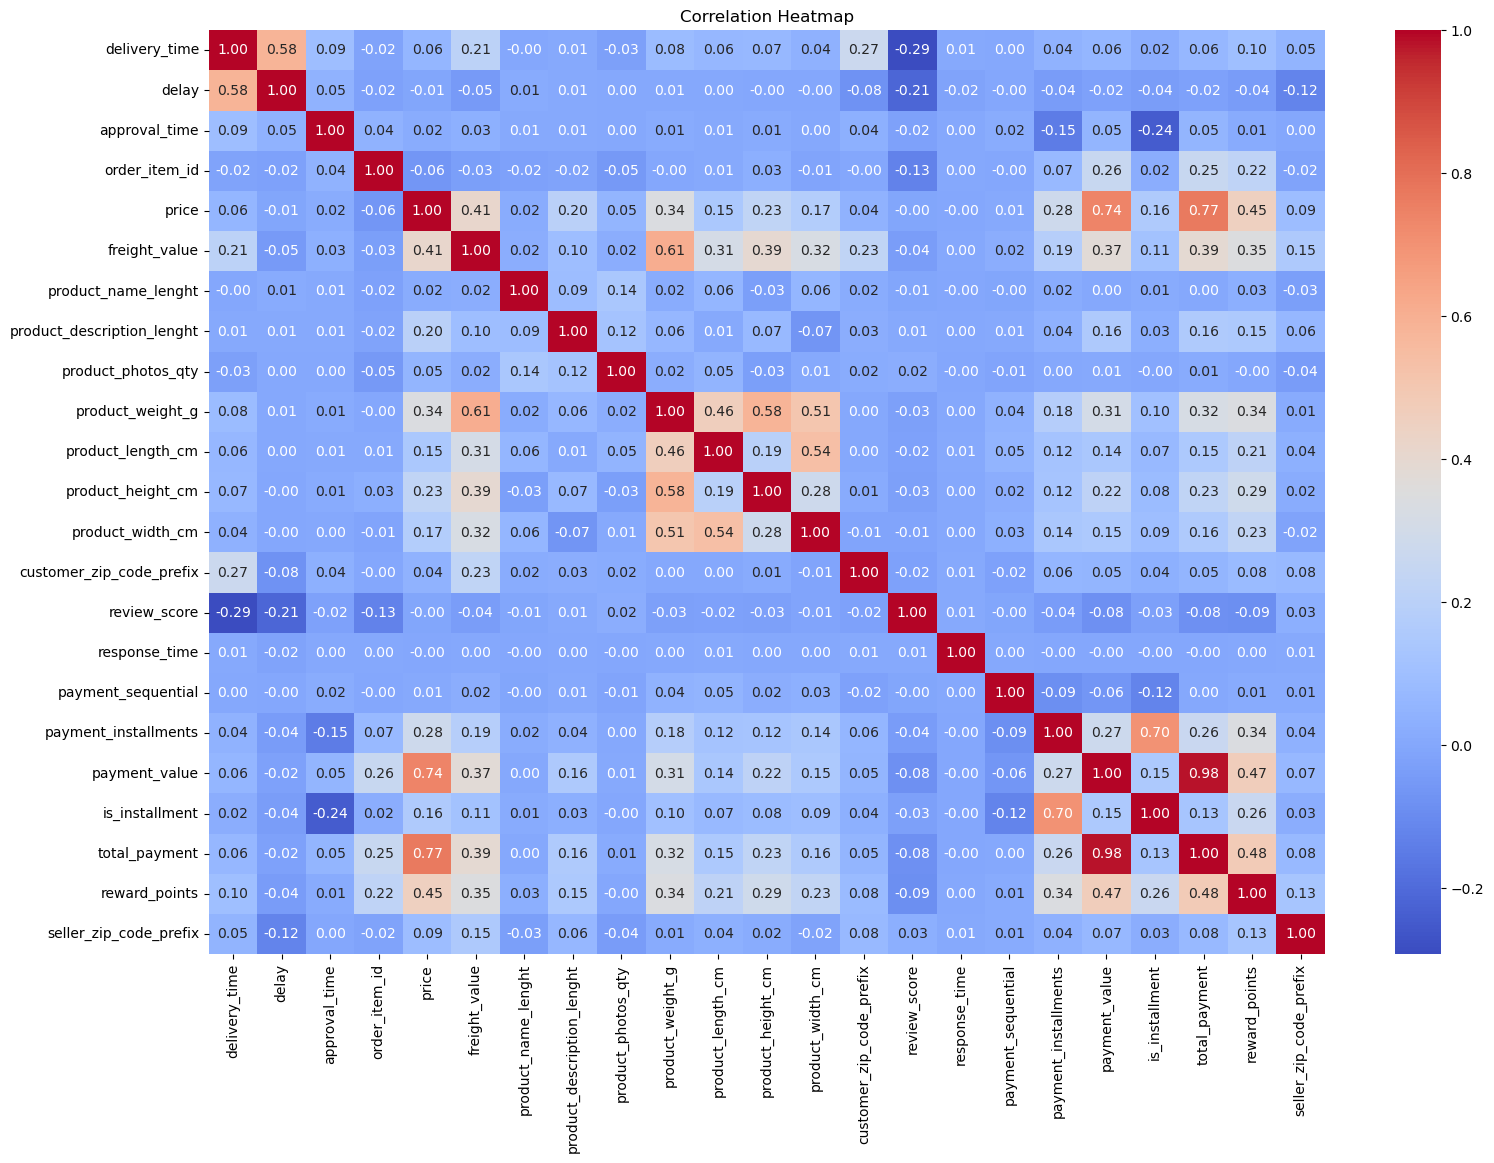

In [159]:
#1
numeric_df = df.select_dtypes(include=['int64', 'float64'])

corr_matrix = numeric_df.corr()

plt.figure(figsize=(18, 12))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()


# some info and visualizations about df without clipping  

In [161]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 117304 entries, 0 to 117303
Data columns (total 57 columns):
 #   Column                         Non-Null Count   Dtype         
---  ------                         --------------   -----         
 0   order_id                       117304 non-null  object        
 1   customer_id                    117304 non-null  object        
 2   order_status                   117304 non-null  object        
 3   order_purchase_timestamp       117304 non-null  datetime64[ns]
 4   order_approved_at              117304 non-null  datetime64[ns]
 5   order_delivered_carrier_date   117304 non-null  datetime64[ns]
 6   order_delivered_customer_date  117304 non-null  datetime64[ns]
 7   order_estimated_delivery_date  117304 non-null  datetime64[ns]
 8   delivery_time                  117304 non-null  int64         
 9   delay                          117304 non-null  int64         
 10  approval_time                  117304 non-null  float64       
 11  

In [162]:
df.describe().transpose()


,count,mean,min,25%,50%,75%,max,std
order_purchase_timestamp,117304,2017-12-30 09:55:29.422159616,2016-09-04 21:15:19,2017-09-11 16:34:38.750000128,2018-01-18 09:24:23.500000,2018-05-03 19:12:02.750000128,2018-09-03 09:06:57,NaN
order_approved_at,117304,2017-12-30 20:25:24.797697280,2016-10-04 09:43:32,2017-09-12 04:26:08,2018-01-18 13:12:59,2018-05-04 03:35:22,2018-09-03 17:40:06,NaN
order_delivered_carrier_date,117304,2018-01-02 16:35:38.980520448,2016-10-06 14:08:38,2017-09-13 22:20:50.750000128,2018-01-22 22:01:23.500000,2018-05-07 14:31:00,2018-09-11 19:48:28,NaN
order_delivered_customer_date,117304,2018-01-11 20:40:53.876926720,2016-10-11 13:46:32,2017-09-21 19:34:22.750000128,2018-01-31 18:42:09.500000,2018-05-14 19:52:11.249999872,2018-10-17 13:22:46,NaN
order_estimated_delivery_date,117304,2018-01-23 06:36:30.493077760,2016-10-20 00:00:00,2017-10-03 00:00:00,2018-02-14 00:00:00,2018-05-25 00:00:00,2018-10-25 00:00:00,NaN
delivery_time,117304.0,11.988645,0.0,6.0,10.0,15.0,208.0,9.278637
delay,117304.0,-12.107294,-147.0,-17.0,-13.0,-7.0,188.0,10.11721
approval_time,117304.0,10.498715,0.0,0.215833,0.346944,14.991667,1450.866389,22.224468
order_status_encoded,117304.0,3.030076,0.0,3.0,3.0,3.0,7.0,0.352672
order_item_id,117304.0,1.194137,1.0,1.0,1.0,1.0,21.0,0.68428


In [163]:
df.describe(include='O').transpose()

,count,unique,top,freq
order_id,117304,97895,895ab968e7bb0d5659d16cd74cd1650c,63
customer_id,117304,97895,270c23a11d024a44c896d1894b261a83,63
order_status,117304,7,delivered,114836
product_id,117304,32776,aca2eb7d00ea1a7b8ebd4e68314663af,533
seller_id,117304,3088,4a3ca9315b744ce9f8e9374361493884,2128
product_category_name,117304,71,cama_mesa_banho,13542
customer_unique_id,117304,94700,9a736b248f67d166d2fbb006bcb877c3,75
customer_city,117304,4108,sao paulo,18581
customer_state,117304,27,SP,49515
review_id,117304,97687,eef5dbca8d37dfce6db7d7b16dd0525e,63


In [164]:
df['order_status'].value_counts(normalize=True) * 100

order_status
delivered      97.896065
shipped         0.994851
canceled        0.469720
invoiced        0.315420
processing      0.315420
unavailable     0.005967
approved        0.002557
Name: proportion, dtype: float64

In [165]:

df['order_purchase_timestamp'].min(), df['order_purchase_timestamp'].max()

(Timestamp('2016-09-04 21:15:19'), Timestamp('2018-09-03 09:06:57'))

In [166]:

df['delay'] = df['delay'].apply(lambda x: x if x >= 0 else 0)


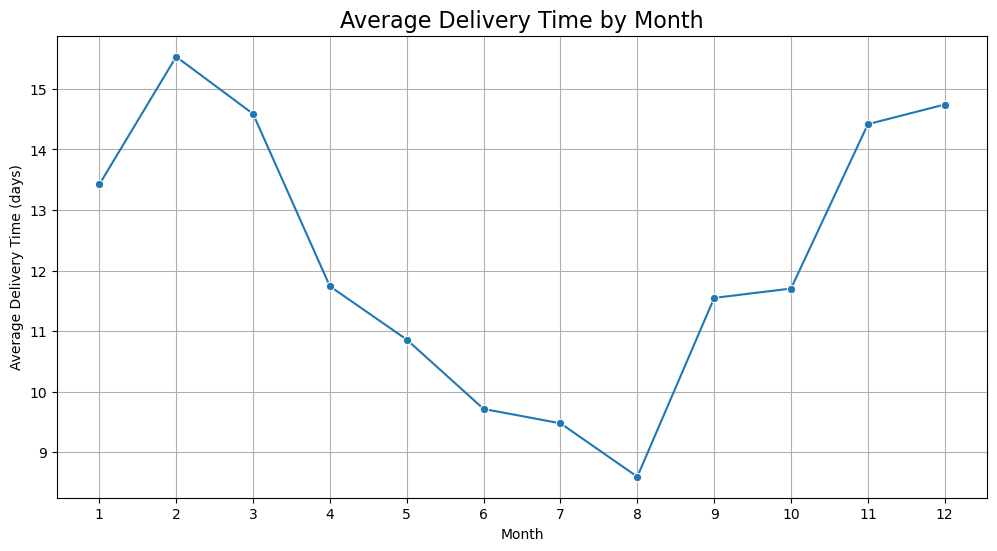

In [167]:

df['purchase_month'] = df['order_purchase_timestamp'].dt.month

monthly_delivery_time = df.groupby('purchase_month')['delivery_time'].mean().reset_index()


plt.figure(figsize=(12, 6))
sns.lineplot(x='purchase_month', y='delivery_time', data=monthly_delivery_time, marker='o')
plt.title('Average Delivery Time by Month', fontsize=16)
plt.xlabel('Month')
plt.ylabel('Average Delivery Time (days)')
plt.xticks(range(1, 13))
plt.grid(True)
plt.show()


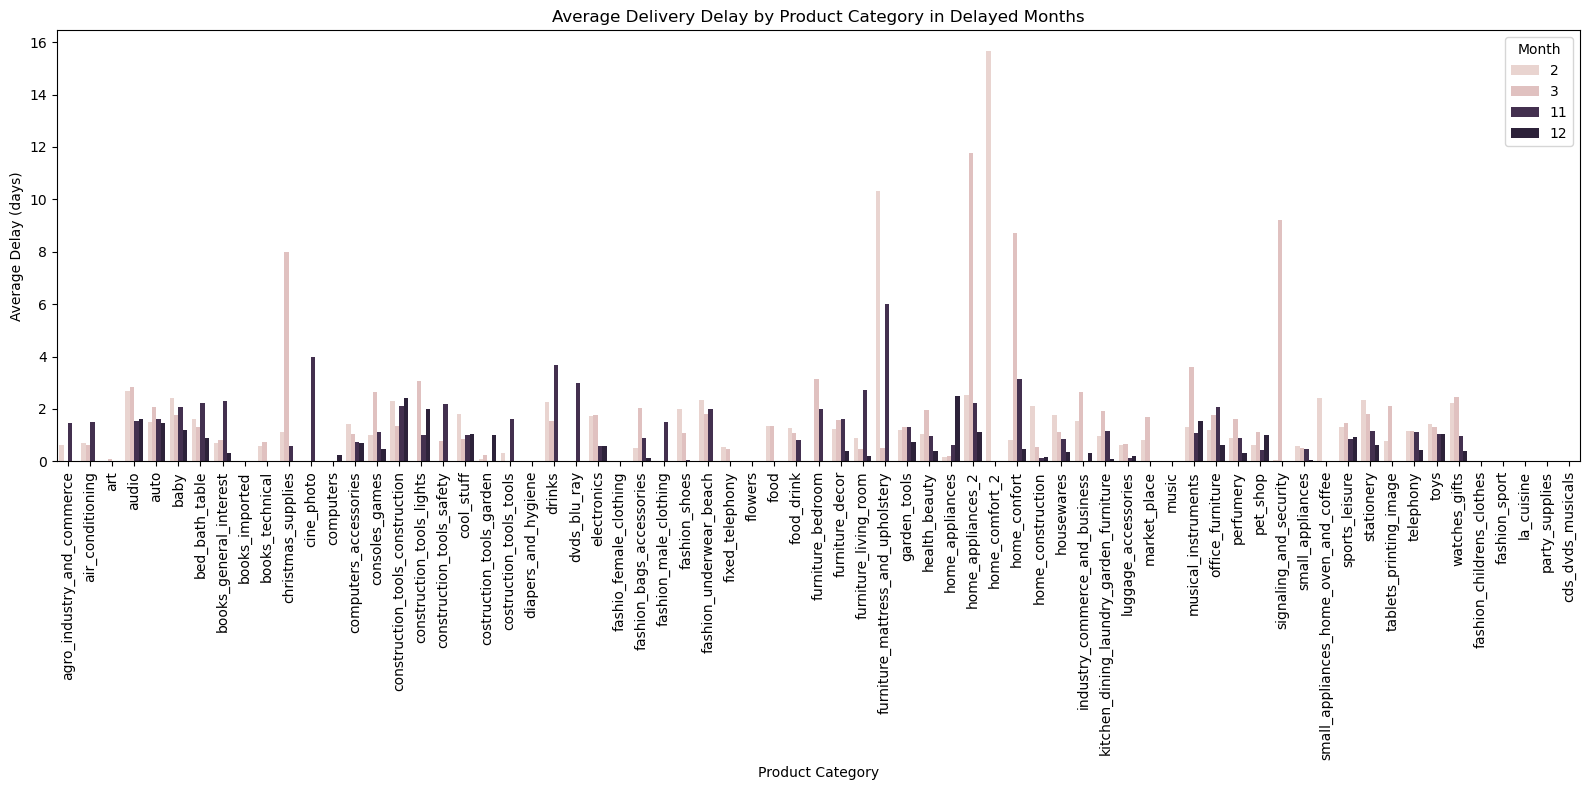

In [168]:

df['month'] = df['order_purchase_timestamp'].dt.month

delay_months = [2, 3, 11, 12]
delayed_df = df[df['month'].isin(delay_months)]

product_delay = delayed_df.groupby(['month', 'product_category_name_english'])['delay'].mean().reset_index()

plt.figure(figsize=(16, 8))
sns.barplot(
    data=product_delay,
    x='product_category_name_english',
    y='delay',
    hue='month'
)
plt.title('Average Delivery Delay by Product Category in Delayed Months')
plt.xlabel('Product Category')
plt.ylabel('Average Delay (days)')
plt.xticks(rotation=90)
plt.legend(title='Month')
plt.tight_layout()
plt.show()


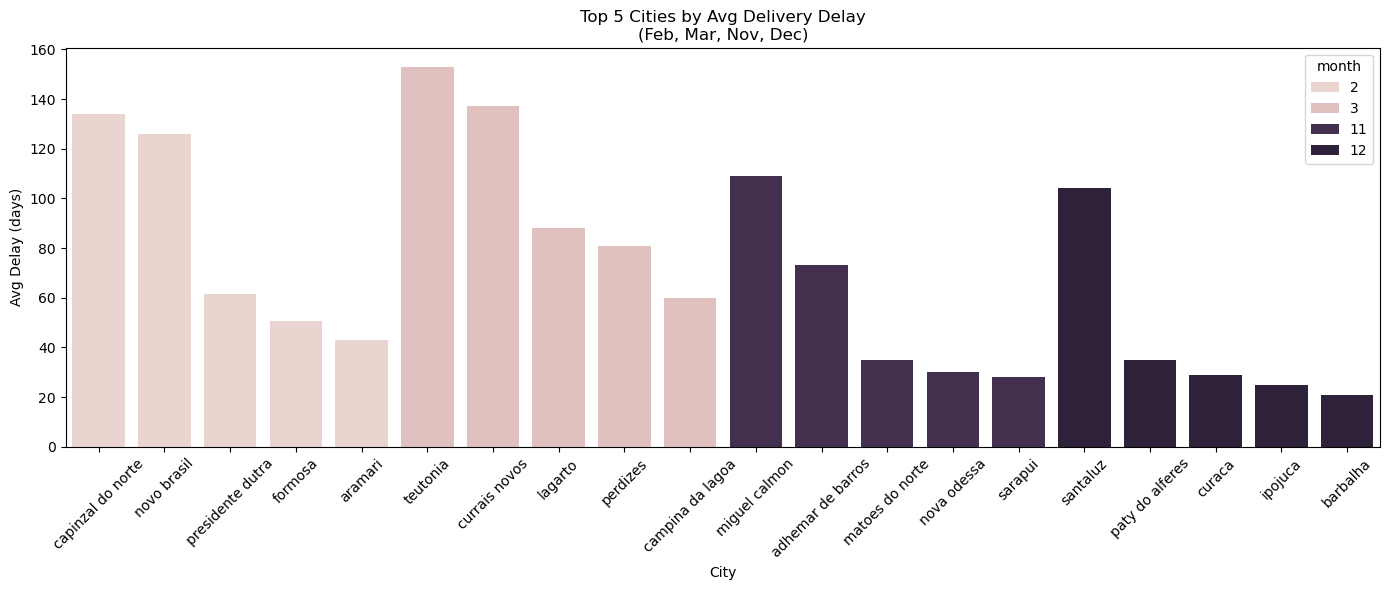

In [170]:

delay_months = [2,3,11,12]
d = df[df['month'].isin(delay_months)]

# 6. Avg delay by city+month
city_delay = (
    d.groupby(['month','customer_city'])['delay']
     .mean()
     .reset_index(name='avg_delay_days')
)

top_cities = (
    city_delay
    .groupby('month', group_keys=False)
    .apply(lambda g: g.nlargest(5,'avg_delay_days'))
    .reset_index(drop=True)
)


plt.figure(figsize=(14,6))
sns.barplot(data=top_cities, x='customer_city', y='avg_delay_days', hue='month')
plt.title('Top 5 Cities by Avg Delivery Delay\n(Feb, Mar, Nov, Dec)')
plt.xlabel('City'); plt.ylabel('Avg Delay (days)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


Average Delivery Delay by Payment Type
  payment_type  avg_delay_days
0       boleto        0.685868
1  credit_card        0.654698
2   debit_card        0.518365
3      voucher        0.714695

Average Delivery Delay by Number of Installments
    payment_installments  avg_delay_days
0                      0        0.000000
1                      1        0.628791
2                      2        0.649872
3                      3        0.632890
4                      4        0.755628
5                      5        0.669998
6                      6        0.802169
7                      7        0.696870
8                      8        0.695558
9                      9        1.065642
10                    10        0.733333
11                    11        1.181818
12                    12        0.597561
13                    13        0.000000
14                    14        2.187500
15                    15        0.758242
16                    16        0.000000
17                

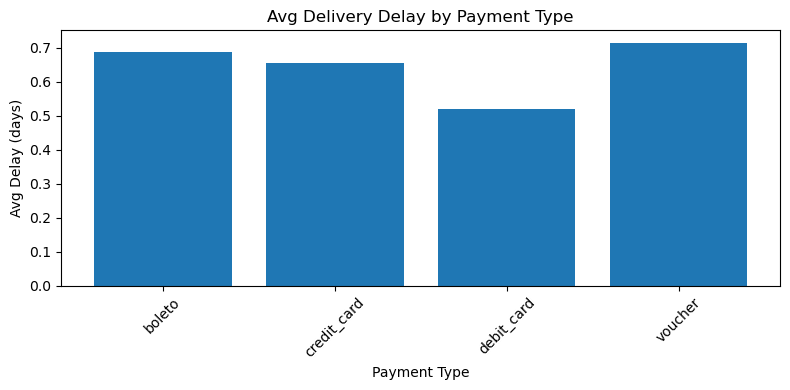

In [173]:

import matplotlib.pyplot as plt

payment_type_delay = (
    df
    .groupby('payment_type')['delay']
    .mean()
    .reset_index(name='avg_delay_days')
)
installment_delay = (
    df
    .groupby('payment_installments')['delay']
    .mean()
    .reset_index(name='avg_delay_days')
)

print("Average Delivery Delay by Payment Type")
print(payment_type_delay)
print("\nAverage Delivery Delay by Number of Installments")
print(installment_delay)

plt.figure(figsize=(8, 4))
plt.bar(payment_type_delay['payment_type'], payment_type_delay['avg_delay_days'])
plt.title('Avg Delivery Delay by Payment Type')
plt.xlabel('Payment Type')
plt.ylabel('Avg Delay (days)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()



Average Review Score by Delivery Delay (0-25 days)
    delay  avg_review_score
0       0          4.154155
1       1          3.618034
2       2          3.079511
3       3          2.555184
4       4          2.458574
5       5          2.138520
6       6          1.829787
7       7          1.867857
8       8          1.713198
9       9          1.729084
10     10          1.562771
11     11          1.678571
12     12          1.666667
13     13          1.747573
14     14          1.682051
15     15          1.698925
16     16          1.666667
17     17          1.648148
18     18          1.623529
19     19          1.651685
20     20          1.592593
21     21          1.670330
22     22          1.837838
23     23          1.414634
24     24          1.553571
25     25          1.585366


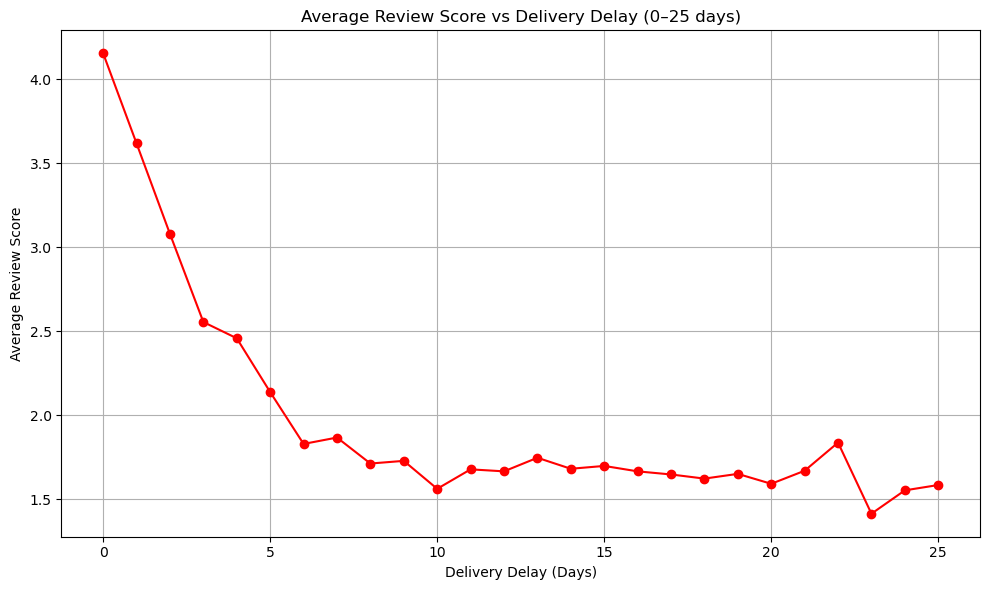

In [174]:

delay_review_correlation = df.groupby('delay')['review_score'].mean().reset_index(name='avg_review_score')

delay_review_correlation_filtered = delay_review_correlation[
    (delay_review_correlation['delay'] >= 0) & 
    (delay_review_correlation['delay'] <= 25)
]

print("Average Review Score by Delivery Delay (0-25 days)")
print(delay_review_correlation_filtered)

plt.figure(figsize=(10, 6))
plt.plot(
    delay_review_correlation_filtered['delay'], 
    delay_review_correlation_filtered['avg_review_score'], 
    marker='o', color='red'
)
plt.title('Average Review Score vs Delivery Delay (0–25 days)')
plt.xlabel('Delivery Delay (Days)')
plt.ylabel('Average Review Score')
plt.grid(True)
plt.tight_layout()
plt.show()


# df_clipped (df without outliers)

In [176]:
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns

df_clipped = df.copy()

for col in numeric_cols:
    Q1 = df_clipped[col].quantile(0.25)
    Q3 = df_clipped[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    df_clipped[col] = df_clipped[col].clip(lower=lower_bound, upper=upper_bound)


In [177]:
df_clipped.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 117304 entries, 0 to 117303
Data columns (total 59 columns):
 #   Column                         Non-Null Count   Dtype         
---  ------                         --------------   -----         
 0   order_id                       117304 non-null  object        
 1   customer_id                    117304 non-null  object        
 2   order_status                   117304 non-null  object        
 3   order_purchase_timestamp       117304 non-null  datetime64[ns]
 4   order_approved_at              117304 non-null  datetime64[ns]
 5   order_delivered_carrier_date   117304 non-null  datetime64[ns]
 6   order_delivered_customer_date  117304 non-null  datetime64[ns]
 7   order_estimated_delivery_date  117304 non-null  datetime64[ns]
 8   delivery_time                  117304 non-null  float64       
 9   delay                          117304 non-null  int64         
 10  approval_time                  117304 non-null  float64       
 11  

In [178]:
df_clipped.describe()

,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,delivery_time,delay,approval_time,order_status_encoded,order_item_id,...,payment_type_encoded,is_installment,total_payment,reward_points,payment_category_encoded,seller_zip_code_prefix,seller_city_encoded,seller_state_encoded,purchase_month,month
count,117304,117304,117304,117304,117304,117304.000000,117304.0,117304.000000,117304.000000,117304.0,...,117304.000000,117304.000000,117304.000000,117304.000000,117304.000000,117304.000000,117304.000000,117304.000000,117304.000000,117304.000000
mean,2017-12-30 09:55:29.422159616,2017-12-30 20:25:24.797697280,2018-01-02 16:35:38.980520448,2018-01-11 20:40:53.876926720,2018-01-23 06:36:30.493077760,11.432884,0.0,8.250778,3.030076,1.0,...,0.980418,0.501355,147.094885,31.863534,1.118265,20829.847495,359.268917,19.445228,6.027118,6.027118
min,2016-09-04 21:15:19,2016-10-04 09:43:32,2016-10-06 14:08:38,2016-10-11 13:46:32,2016-10-20 00:00:00,0.000000,0.0,0.000000,0.000000,1.0,...,0.000000,0.000000,9.590000,10.000000,0.000000,1001.000000,0.000000,0.000000,1.000000,1.000000
25%,2017-09-11 16:34:38.750000128,2017-09-12 04:26:08,2017-09-13 22:20:50.750000128,2017-09-21 19:34:22.750000128,2017-10-03 00:00:00,6.000000,0.0,0.215833,3.000000,1.0,...,1.000000,0.000000,65.497500,25.000000,0.000000,6429.000000,227.000000,19.000000,3.000000,3.000000
50%,2018-01-18 09:24:23.500000,2018-01-18 13:12:59,2018-01-22 22:01:23.500000,2018-01-31 18:42:09.500000,2018-02-14 00:00:00,10.000000,0.0,0.346944,3.000000,1.0,...,1.000000,1.000000,113.830000,25.000000,1.000000,13660.000000,420.000000,22.000000,6.000000,6.000000
75%,2018-05-03 19:12:02.750000128,2018-05-04 03:35:22,2018-05-07 14:31:00,2018-05-14 19:52:11.249999872,2018-05-25 00:00:00,15.000000,0.0,14.991667,3.000000,1.0,...,1.000000,1.000000,195.000000,50.000000,2.000000,28470.000000,517.000000,22.000000,8.000000,8.000000
max,2018-09-03 09:06:57,2018-09-03 17:40:06,2018-09-11 19:48:28,2018-10-17 13:22:46,2018-10-25 00:00:00,28.500000,0.0,37.155417,7.000000,1.0,...,4.000000,1.000000,389.253750,50.000000,2.000000,61531.500000,610.000000,22.000000,12.000000,12.000000
std,NaN,NaN,NaN,NaN,NaN,6.982928,0.0,13.007765,0.352672,0.0,...,0.830975,0.500000,106.446588,14.669879,0.913682,19678.193359,165.721084,4.838359,3.230093,3.230093


In [179]:
df_clipped.describe(include='O')

,order_id,customer_id,order_status,product_id,seller_id,product_category_name,customer_unique_id,customer_city,customer_state,review_id,review_comment_title,review_comment_message,payment_type,payment_category,seller_city,seller_state,product_category_name_english
count,117304,117304,117304,117304,117304,117304,117304,117304,117304,117304,117304,117304,117304,117304,117304,117304,117304
unique,97895,97895,7,32776,3088,71,94700,4108,27,97687,4495,35683,4,3,611,23,71
top,895ab968e7bb0d5659d16cd74cd1650c,270c23a11d024a44c896d1894b261a83,delivered,aca2eb7d00ea1a7b8ebd4e68314663af,4a3ca9315b744ce9f8e9374361493884,cama_mesa_banho,9a736b248f67d166d2fbb006bcb877c3,sao paulo,SP,eef5dbca8d37dfce6db7d7b16dd0525e,No Title,No Comment,credit_card,medium,sao paulo,SP,bed_bath_table
freq,63,63,114836,533,2128,13542,75,18581,49515,63,103421,67637,86507,56720,29040,83646,13542


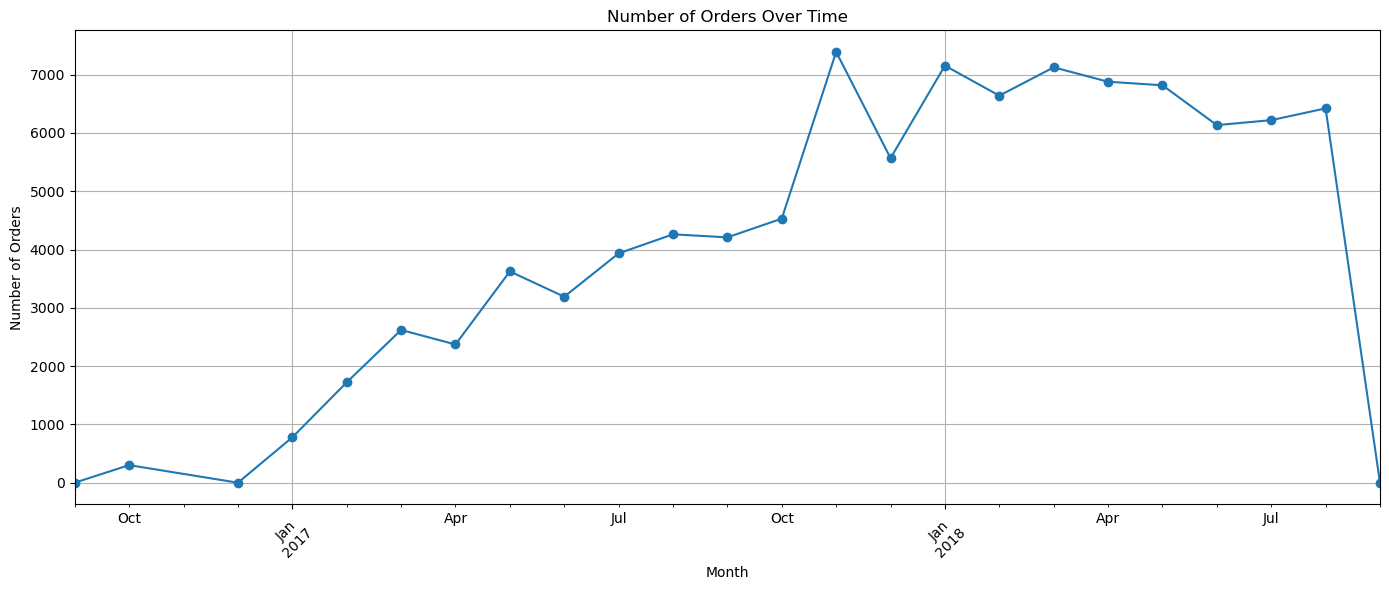

In [180]:
#7
df_clipped['order_purchase_month'] = df_clipped['order_purchase_timestamp'].dt.to_period('M')

monthly_orders = df_clipped.groupby('order_purchase_month')['order_id'].nunique()

plt.figure(figsize=(14, 6))
monthly_orders.plot(kind='line', marker='o')
plt.title('Number of Orders Over Time')
plt.xlabel('Month')
plt.ylabel('Number of Orders')
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


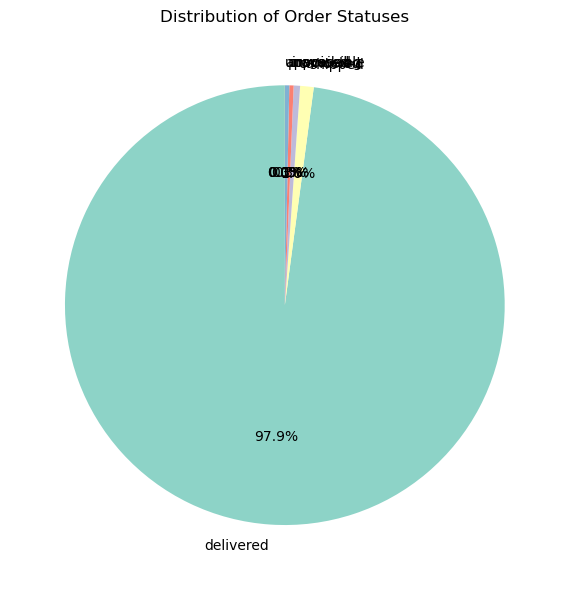

In [182]:
#8
order_status_counts = df_clipped['order_status'].value_counts()

plt.figure(figsize=(8, 6))
order_status_counts.plot(kind='pie', autopct='%1.1f%%', startangle=90, colors=plt.cm.Set3.colors)
plt.title('Distribution of Order Statuses')
plt.ylabel('')
plt.tight_layout()
plt.show()


In [183]:
delivery_stats = df_clipped[['delivery_time', 'delay']].agg(['mean', 'median', 'std', 'max', 'min'])
print("Delivery and Delay Statistics (After Clipping):")
delivery_stats


Delivery and Delay Statistics (After Clipping):


,delivery_time,delay
mean,11.432884,0.0
median,10.000000,0.0
std,6.982928,0.0
max,28.500000,0.0
min,0.000000,0.0


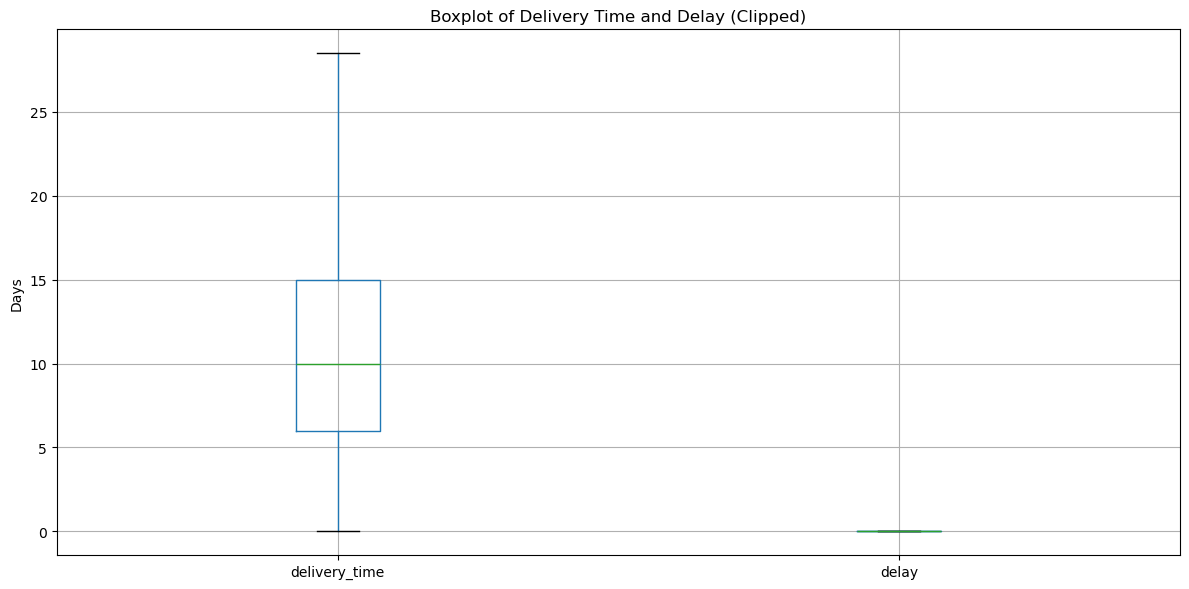

In [184]:
plt.figure(figsize=(12, 6))
df_clipped[['delivery_time', 'delay']].boxplot()
plt.title('Boxplot of Delivery Time and Delay (Clipped)')
plt.ylabel('Days')
plt.grid(True)
plt.tight_layout()
plt.show()


In [187]:
seller_state_counts = df_clipped.groupby('seller_state').size().reset_index(name='num_sellers')
seller_state_counts = seller_state_counts.sort_values(by='num_sellers', ascending=False)


In [188]:
seller_state_counts

,seller_state,num_sellers
22,SP,83646
8,MG,9228
15,PR,9029
16,RJ,4991
20,SC,4240
19,RS,2272
4,DF,948
2,BA,698
6,GO,547
13,PE,461


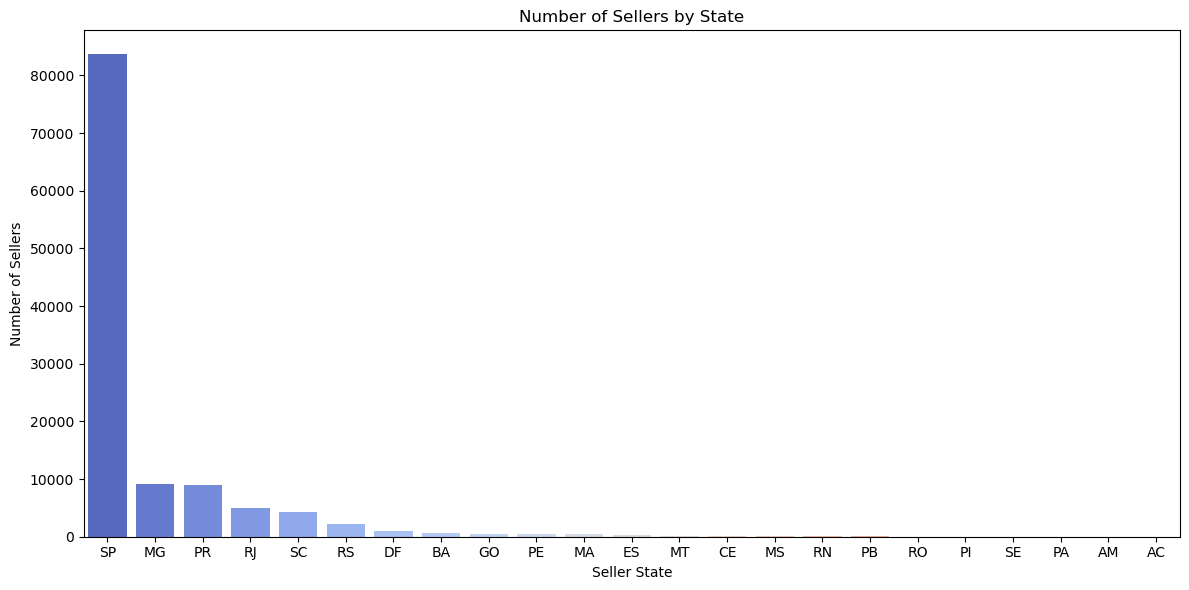

In [189]:
#10
plt.figure(figsize=(12, 6))
sns.barplot(data=seller_state_counts, x='seller_state', y='num_sellers', palette='coolwarm')
plt.title('Number of Sellers by State')
plt.xlabel('Seller State')
plt.ylabel('Number of Sellers')
plt.tight_layout()
plt.show()


In [191]:
top_sellers_review = df_clipped.groupby('seller_id')['review_score'].mean().reset_index()
top_sellers_review = top_sellers_review.sort_values(by='review_score', ascending=False).head(10)


In [192]:
top_sellers_review

,seller_id,review_score
1775,9140ef75cc8211c4035935e80e567204,5.0
1845,979e9f8b5b39dd243a2550c8b05aecf0,5.0
2044,a9b533a26e898b12e8b8d4c07279bf4d,5.0
1277,695051e2981c8b19e77cafe450d5bdf3,5.0
1279,698624c6632eeba1774924dbea24c700,5.0
2751,e5545d4d4473876ea78c5bcebca365c3,5.0
2043,a9ae440659f48b7849df83e82734150b,5.0
2583,d63f306de130e0391d38a792541723b8,5.0
369,1f7fd2a6fcd5a6fa5d8a4dabc72aaae0,5.0
1283,69b5eaa096c3f9d1e5c398c597f567d6,5.0


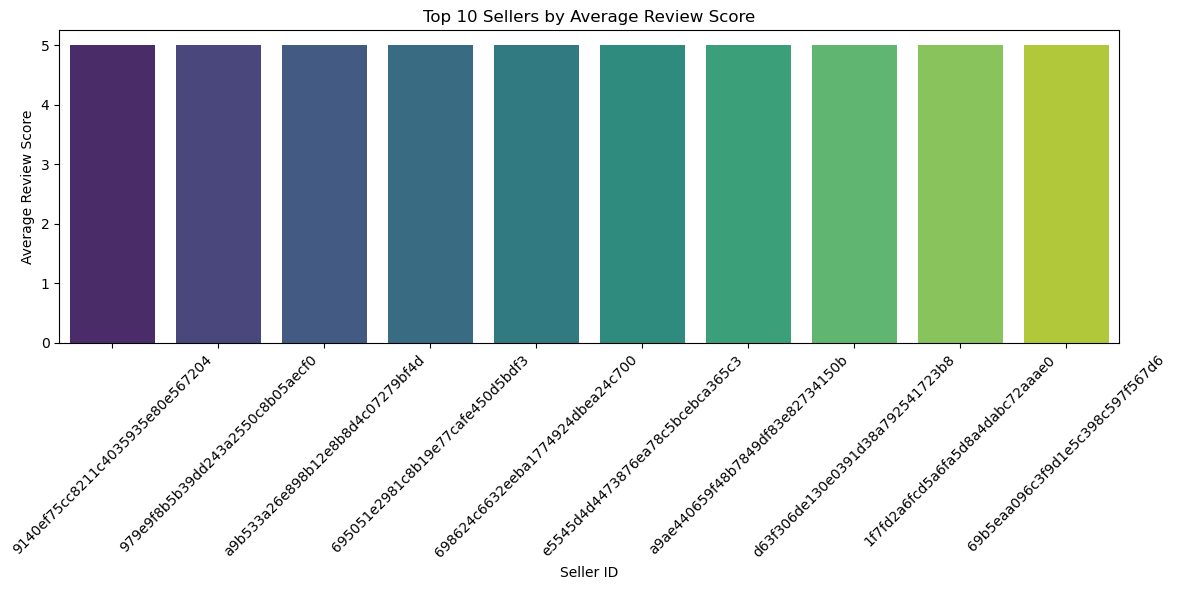

In [193]:
#11
#plot top 10 sellers by review score 
plt.figure(figsize=(12, 6))
sns.barplot(data=top_sellers_review, x='seller_id', y='review_score', palette='viridis')
plt.xticks(rotation=45)
plt.title('Top 10 Sellers by Average Review Score')
plt.xlabel('Seller ID')
plt.ylabel('Average Review Score')
plt.tight_layout()
plt.show()


In [196]:
shipping_time = df_clipped.groupby('seller_id')['delivery_time'].mean().reset_index(name='avg_shipping_days')
shipping_time = shipping_time.sort_values(by='avg_shipping_days', ascending=False).head(10)


In [197]:
shipping_time

,seller_id,avg_shipping_days
1890,9bf11dfc0bec77e5a23028043c3c5a8f,28.5
1267,685b870da5b52a710782c9c0fefbeb5b,28.5
2715,e1c76f339ebd5460999f25a2aa8c92c5,28.5
1324,6d04126aba80df143fd038e711b8fd96,28.5
2285,be1e9e378700cecaa4ebf71433d7915c,28.5
1074,586a871d4f1221763fddb6ceefdeb95e,28.5
2631,da2782c804606d2a5d8e1760dbb3e7ec,28.5
2239,baf15155e37ef5492731459bdc05be8a,28.5
618,344223b2a90784f64136a8a5da012e7f,28.5
2409,c7b7db6c8f3c64a7cc1afa634db21d50,28.5


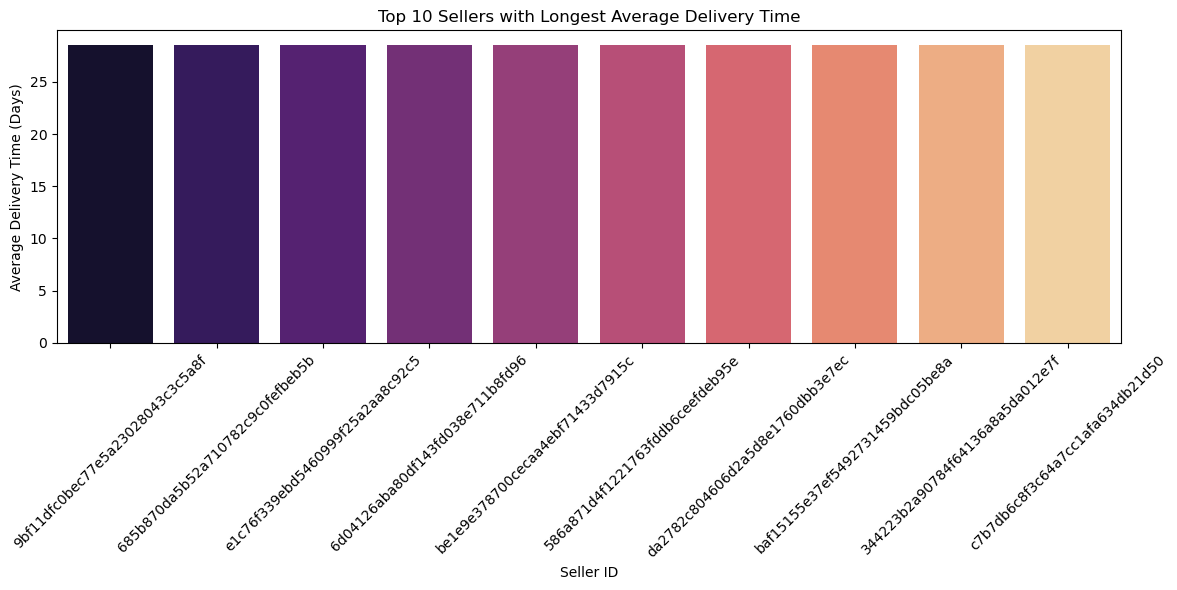

In [198]:
#12
plt.figure(figsize=(12, 6))
sns.barplot(data=shipping_time, x='seller_id', y='avg_shipping_days', palette='magma')
plt.xticks(rotation=45)
plt.title('Top 10 Sellers with Longest Average Delivery Time')
plt.xlabel('Seller ID')
plt.ylabel('Average Delivery Time (Days)')
plt.tight_layout()
plt.show()


# Do sellers who ship faster receive higher ratings?

In [200]:
seller_delivery_review = df_clipped.groupby('seller_id').agg(
    avg_delivery_time=('delivery_time', 'mean'),
    avg_review_score=('review_score', 'mean'),
    num_orders=('order_id', 'count')
).reset_index()


In [201]:
seller_delivery_review

,seller_id,avg_delivery_time,avg_review_score,num_orders
0,0015a82c2db000af6aaaf3ae2ecb0532,10.333333,4.166667,3
1,001cca7ae9ae17fb1caed9dfb1094831,12.010504,4.149160,238
2,001e6ad469a905060d959994f1b41e4f,12.000000,2.500000,1
3,002100f778ceb8431b7a1020ff7ab48f,14.822034,4.220339,59
4,003554e2dce176b5555353e4f3555ac8,4.000000,5.000000,1
...,...,...,...,...
3083,ffcfefa19b08742c5d315f2791395ee5,12.000000,2.500000,1
3084,ffdd9f82b9a447f6f8d4b91554cc7dd3,9.761905,4.404762,21
3085,ffeee66ac5d5a62fe688b9d26f83f534,17.178571,4.428571,14
3086,fffd5413c0700ac820c7069d66d98c89,12.385246,4.131148,61


In [203]:
filtered_sellers = seller_delivery_review[seller_delivery_review['num_orders'] >= 20]
filtered_sellers

,seller_id,avg_delivery_time,avg_review_score,num_orders
1,001cca7ae9ae17fb1caed9dfb1094831,12.010504,4.149160,238
3,002100f778ceb8431b7a1020ff7ab48f,14.822034,4.220339,59
5,004c9cd9d87a3c30c522c48c4fc07416,13.041262,4.230583,206
6,00720abe85ba0859807595bbf045a33b,7.711538,3.884615,26
9,00ee68308b45bc5e2660cd833c3f81cc,7.944149,4.438830,188
...,...,...,...,...
3078,ff69aa92bb6b1bf9b8b7a51c2ed9cf8b,9.571429,4.095238,21
3082,ffc470761de7d0232558ba5e786e57b7,9.312500,4.375000,32
3084,ffdd9f82b9a447f6f8d4b91554cc7dd3,9.761905,4.404762,21
3086,fffd5413c0700ac820c7069d66d98c89,12.385246,4.131148,61


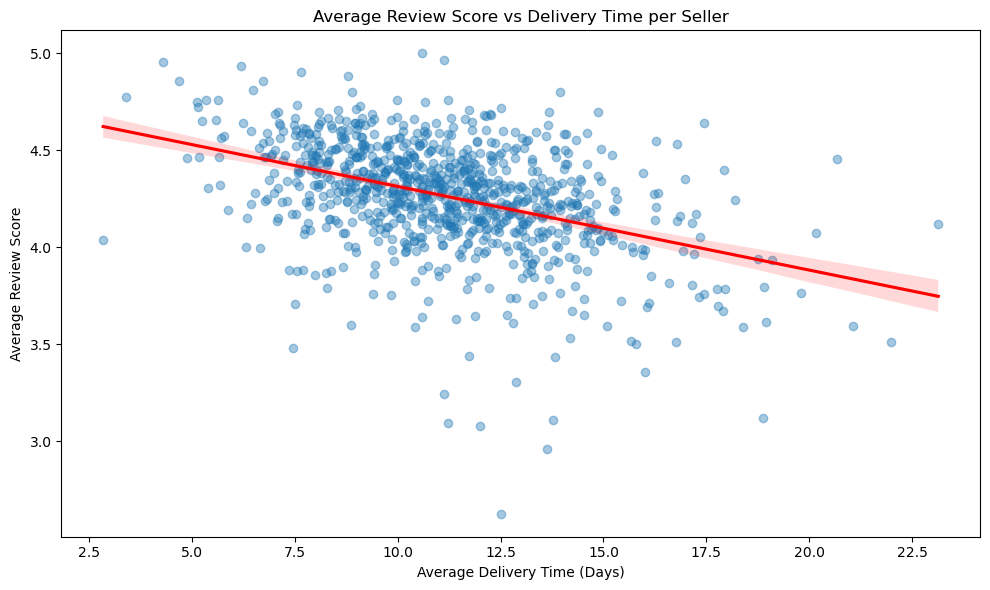

In [204]:
#13
plt.figure(figsize=(10, 6))
sns.regplot(
    data=filtered_sellers,
    x='avg_delivery_time',
    y='avg_review_score',
    scatter_kws={'alpha': 0.4},
    line_kws={'color': 'red'}
)
plt.title('Average Review Score vs Delivery Time per Seller')
plt.xlabel('Average Delivery Time (Days)')
plt.ylabel('Average Review Score')
plt.tight_layout()
plt.show()
 # kol point 3bara 3n ba23 
# x by2ol ad eh wa2t el tawsel byakhod w y by2ol ad eh score wl regression line da bythbt en f3ln el scor by2l bsbb el ta2kher w taht asbtna bl corr
#el corr hyt3 bl negative 3shan el 3laka benhom 3ksya 

In [205]:
correlation = filtered_sellers['avg_delivery_time'].corr(filtered_sellers['avg_review_score'])
print(f"Correlation between Delivery Time and Review Score: {correlation:.2f}")


Correlation between Delivery Time and Review Score: -0.42


# 14 What are the top 10 most popular product categories in our e-commerce store?

Top 10 Most Common Product Categories:
product_category_name_english
bed_bath_table           13542
health_beauty             9944
sports_leisure            8942
furniture_decor           8743
computers_accessories     8105
housewares                7331
watches_gifts             6161
telephony                 4692
garden_tools              4558
auto                      4356
Name: count, dtype: int64


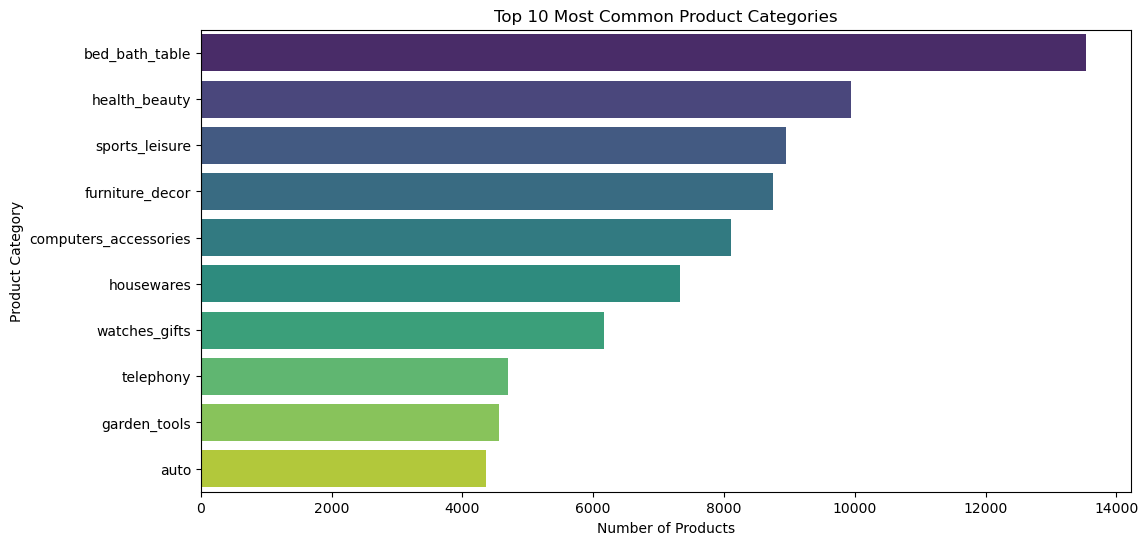

In [207]:
#14
# Analyze most common product categories
top_categories = df_clipped['product_category_name_english'].value_counts().head(10)

# Display results
print("Top 10 Most Common Product Categories:")
print(top_categories)

# Plot
plt.figure(figsize=(12, 6))
sns.barplot(x=top_categories.values, y=top_categories.index, palette='viridis')
plt.title('Top 10 Most Common Product Categories')
plt.xlabel('Number of Products')
plt.ylabel('Product Category')
plt.show()

# 15 what is the Relationship between physical features and price/review score?

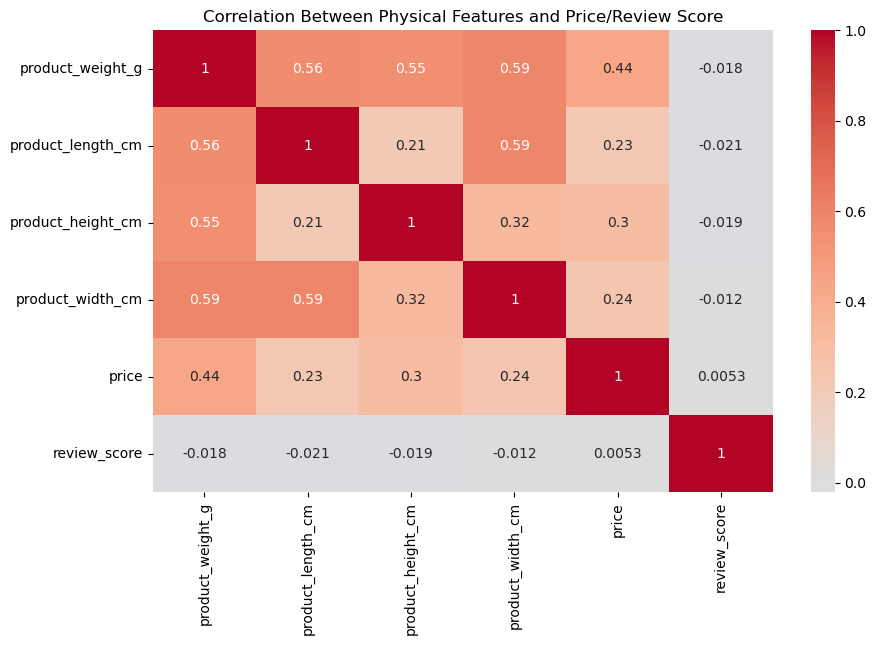

In [209]:
#15
physical_features = ['product_weight_g', 'product_length_cm', 
                    'product_height_cm', 'product_width_cm']
targets = ['price', 'review_score']

correlation_matrix = df_clipped[physical_features + targets].corr()
plt.figure(figsize=(10, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0)
plt.title('Correlation Between Physical Features and Price/Review Score')
plt.show()

#  16 Are some product categories more expensive than others? And are high prices common or rare?

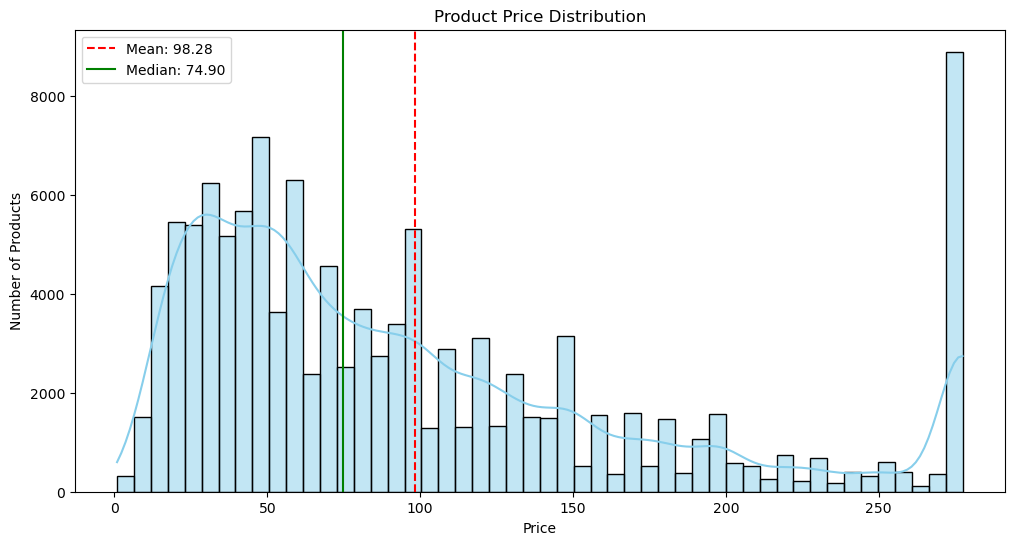

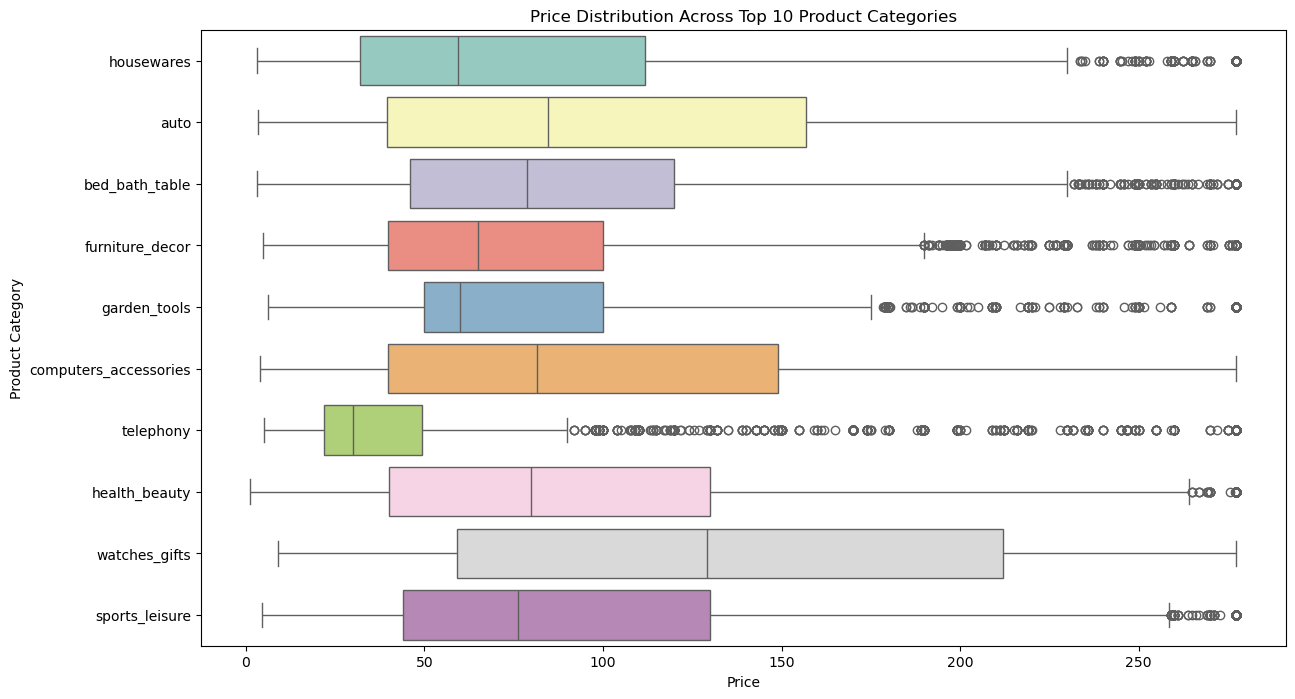

In [211]:
#16
plt.figure(figsize=(12, 6))

sns.histplot(df_clipped['price'], bins=50, kde=True, color='skyblue')
plt.title('Product Price Distribution')
plt.xlabel('Price')
plt.ylabel('Number of Products')

mean_price = df_clipped['price'].mean()
median_price = df_clipped['price'].median()
plt.axvline(mean_price, color='red', linestyle='--', label=f'Mean: {mean_price:.2f}')
plt.axvline(median_price, color='green', linestyle='-', label=f'Median: {median_price:.2f}')
plt.legend()
plt.show()

plt.figure(figsize=(14, 8))
top_cats = df_clipped['product_category_name_english'].value_counts().head(10).index
sns.boxplot(data=df_clipped[df_clipped['product_category_name_english'].isin(top_cats)],
            x='price', y='product_category_name_english', palette='Set3')
plt.title('Price Distribution Across Top 10 Product Categories')
plt.xlabel('Price')
plt.ylabel('Product Category')
plt.show()

# 17 What are the most commonly used payment methods by customers?

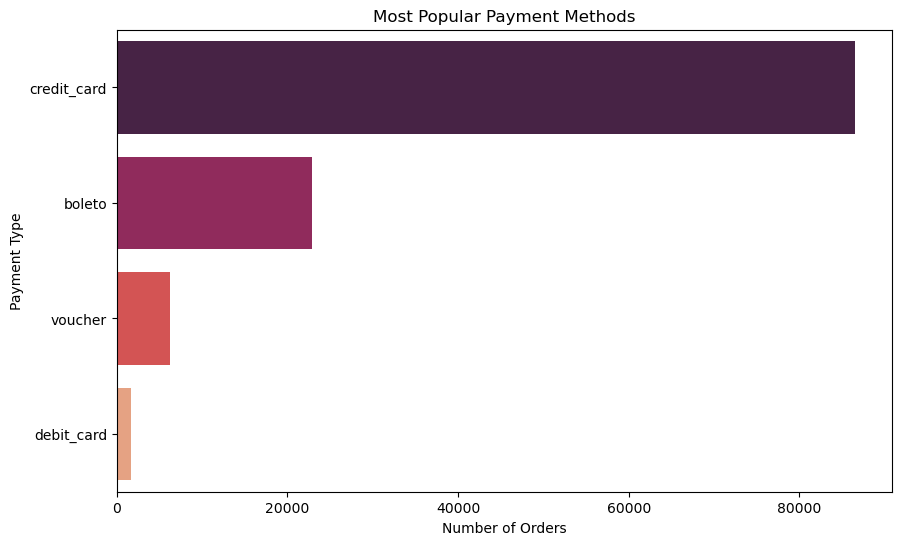

In [213]:
#17
payment_counts = df_clipped['payment_type'].value_counts()

plt.figure(figsize=(10, 6))
sns.barplot(x=payment_counts.values, y=payment_counts.index, palette='rocket')
plt.title('Most Popular Payment Methods')
plt.xlabel('Number of Orders')
plt.ylabel('Payment Type')
plt.show()


# 19 Do customers who pay in installments give different review scores compared to those who pay in full?

Installment Orders: 50.14%


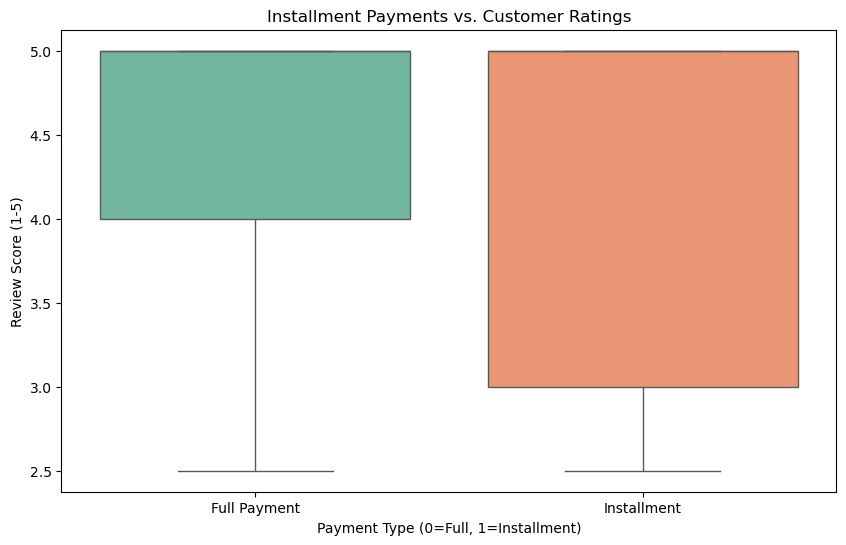

In [215]:
#19
# % of orders with installments
installment_percentage = df_clipped['is_installment'].mean() * 100
print(f"Installment Orders: {installment_percentage:.2f}%")

# Installments vs. Ratings
plt.figure(figsize=(10, 6))
sns.boxplot(data=df_clipped, x='is_installment', y='review_score', palette='Set2')
plt.title('Installment Payments vs. Customer Ratings')
plt.xlabel('Payment Type (0=Full, 1=Installment)')
plt.ylabel('Review Score (1-5)')
plt.xticks([0, 1], ['Full Payment', 'Installment'])
plt.show()


In [216]:
correlation = df_clipped[['is_installment', 'review_score']].corr()
print("Correlation between installment payments and review scores:")
print(correlation)


Correlation between installment payments and review scores:
                is_installment  review_score
is_installment        1.000000     -0.025415
review_score         -0.025415      1.000000


# 20 How are customer review scores distributed?

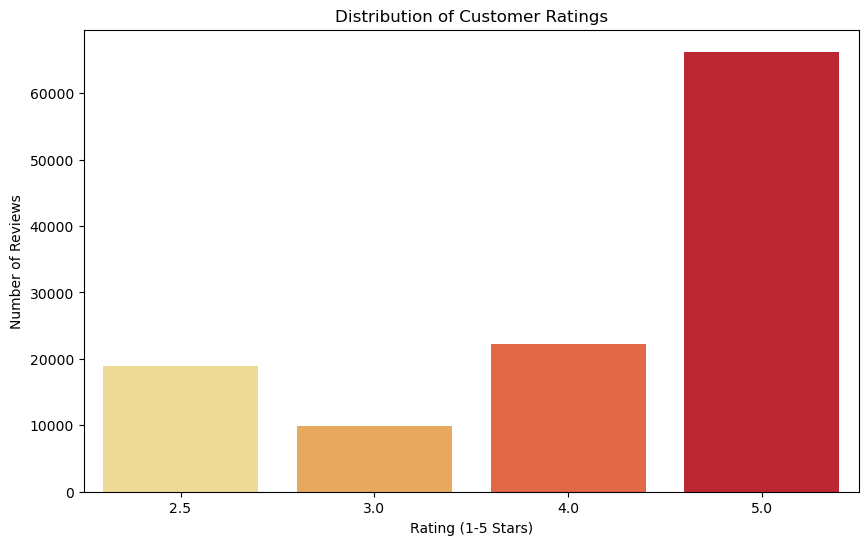

In [218]:
#20
plt.figure(figsize=(10, 6))
sns.countplot(x='review_score', data=df_clipped, palette='YlOrRd')
plt.title('Distribution of Customer Ratings')
plt.xlabel('Rating (1-5 Stars)')
plt.ylabel('Number of Reviews')
plt.show()

# 21 Does delivery time affect customer ratings?

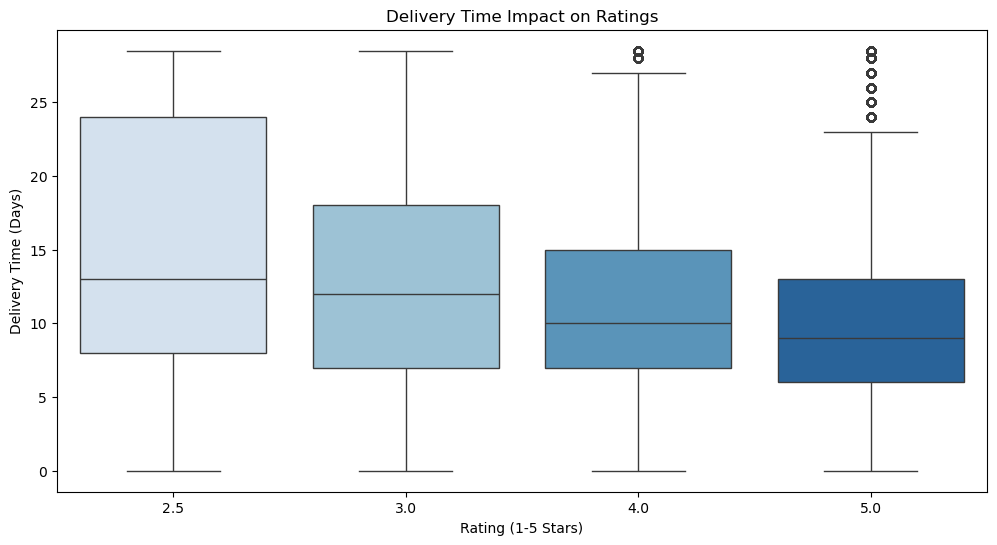

In [220]:
# 21
plt.figure(figsize=(12, 6))
sns.boxplot(x='review_score', y='delivery_time', data=df_clipped, palette='Blues')
plt.title('Delivery Time Impact on Ratings')
plt.xlabel('Rating (1-5 Stars)')
plt.ylabel('Delivery Time (Days)')
plt.show()

# 22 Do customers who leave a comment give different ratings than those who don't?

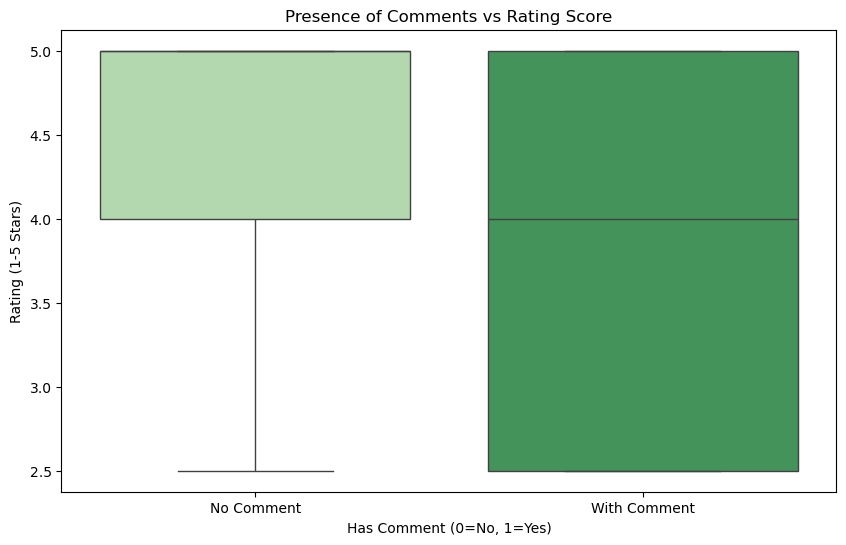

In [222]:
#22
plt.figure(figsize=(10, 6))
sns.boxplot(x='has_comment', y='review_score', data=df_clipped, palette='Greens')
plt.title('Presence of Comments vs Rating Score')
plt.xlabel('Has Comment (0=No, 1=Yes)')
plt.ylabel('Rating (1-5 Stars)')
plt.xticks([0, 1], ['No Comment', 'With Comment'])
plt.show()

# 23 What is the difference between estimated and actual delivery dates?

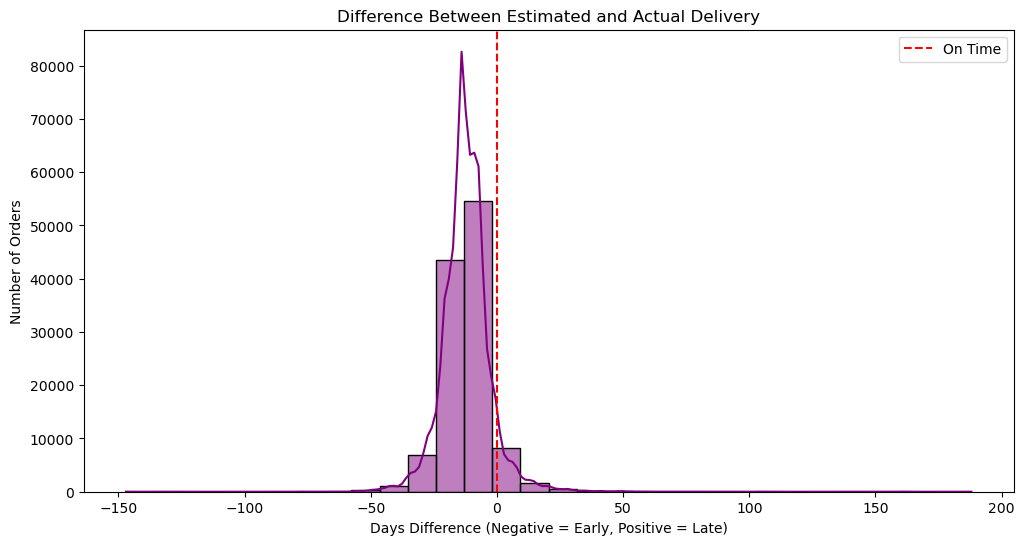

الطلبات التي وصلت مبكراً: 92.3%
الطلبات التي وصلت في الموعد: 1.3%
الطلبات التي وصلت متأخرة: 6.4%


In [224]:
#23
df_clipped['delivery_difference'] = (df_clipped['order_delivered_customer_date'] - df_clipped['order_estimated_delivery_date']).dt.days

plt.figure(figsize=(12, 6))
sns.histplot(df_clipped['delivery_difference'], bins=30, kde=True, color='purple')
plt.axvline(0, color='red', linestyle='--', label='On Time')
plt.title('Difference Between Estimated and Actual Delivery')
plt.xlabel('Days Difference (Negative = Early, Positive = Late)')
plt.ylabel('Number of Orders')
plt.legend()
plt.show()

early = (df_clipped['delivery_difference'] < 0).mean() * 100
on_time = (df_clipped['delivery_difference'] == 0).mean() * 100
late = (df_clipped['delivery_difference'] > 0).mean() * 100

print(f'الطلبات التي وصلت مبكراً: {early:.1f}%')
print(f'الطلبات التي وصلت في الموعد: {on_time:.1f}%')
print(f'الطلبات التي وصلت متأخرة: {late:.1f}%')

# 25 Which customers bring in the most revenue?

In [226]:
top_customers = df_clipped.groupby('customer_unique_id').agg({
    'order_id': 'count',
    'payment_value': 'sum',
    'review_score': 'mean'
}).sort_values('payment_value', ascending=False).head(10)

top_customers

,order_id,payment_value,review_score
customer_unique_id,,,
c8460e4251689ba205045f3ea17884a1,24,9155.7000,4.000000
d97b3cfb22b0d6b25ac9ed4e9c2d481b,24,8773.0850,2.500000
c402f431464c72e27330a67f7b94d4fb,20,7629.7500,2.500000
0f5ac8d5c31de21d2f25e24be15bbffb,18,6679.8225,5.000000
11f97da02237a49c8e783dfda6f50e8e,15,5722.3125,5.000000
eae0a83d752b1dd32697e0e7b4221656,15,5722.3125,3.000000
33176de67c05eeed870fd49f234387a0,15,5537.2175,2.566667
f7ea4eef770a388bd5b225acfc546604,14,5340.8250,2.500000
31e412b9fb766b6794724ed17a41dfa6,14,5340.8250,2.500000


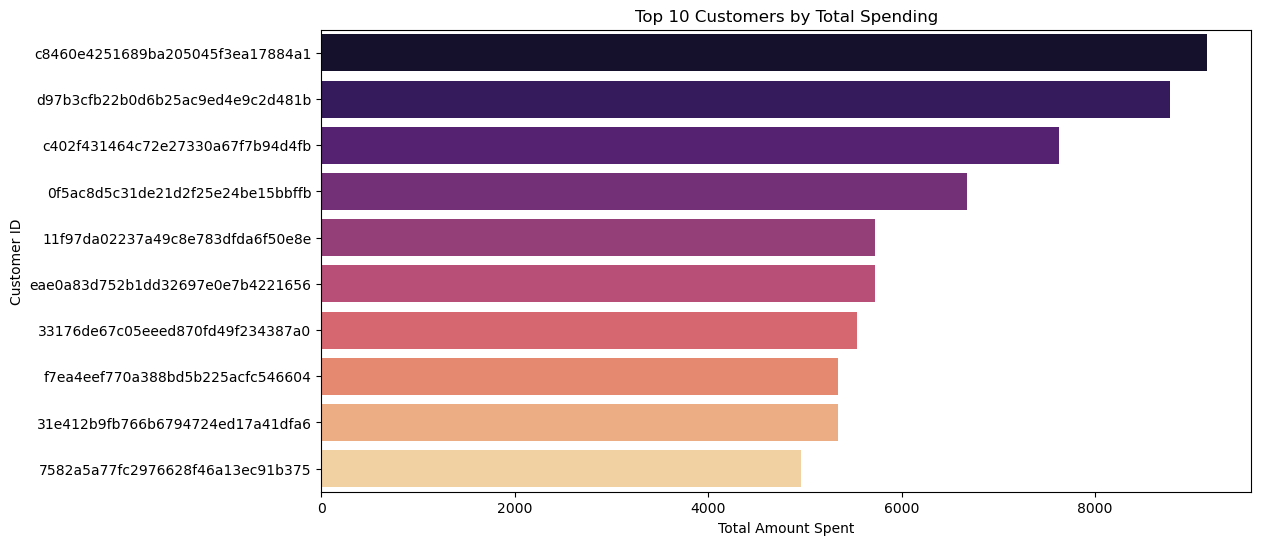

In [227]:
#25
plt.figure(figsize=(12,6))
sns.barplot(x=top_customers['payment_value'], y=top_customers.index, palette='magma')
plt.title('Top 10 Customers by Total Spending')
plt.xlabel('Total Amount Spent')
plt.ylabel('Customer ID')
plt.show()

# 26 Which sellers have the highest average review scores, and which have the lowest?

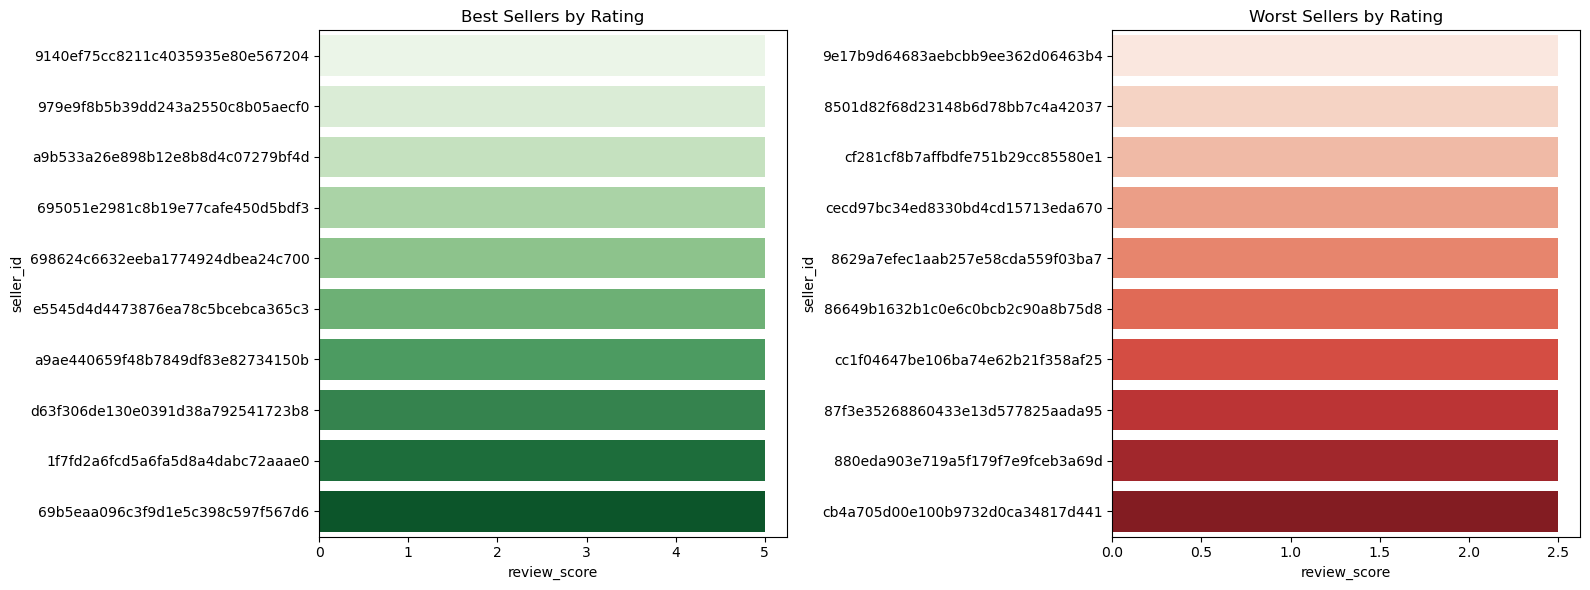

In [229]:
# 26
top_sellers = df_clipped.groupby('seller_id').agg({
    'review_score': 'mean',
    'order_id': 'count'
}).sort_values('review_score', ascending=False).head(10)

worst_sellers = df_clipped.groupby('seller_id').agg({
    'review_score': 'mean',
    'order_id': 'count'
}).sort_values('review_score').head(10)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16,6))
sns.barplot(x=top_sellers['review_score'], y=top_sellers.index, ax=ax1, palette='Greens')
sns.barplot(x=worst_sellers['review_score'], y=worst_sellers.index, ax=ax2, palette='Reds')
ax1.set_title('Best Sellers by Rating')
ax2.set_title('Worst Sellers by Rating')
plt.tight_layout()
plt.show()

In [230]:
#df_clipped.to_csv("C:\\Users\\hp\\Downloads\\archive (7)\\df_clipped.csv", index=False)